# Notebook 4 — Harmonised Full Walk-Forward LSTM Training and Evaluation on M15

This notebook is the final harmonised LSTM experiment for the master’s capstone. It replaces the earlier completed LSTM development run for final cross-model comparison while preserving that earlier run as an archived internal experiment.

The notebook evaluates four tracks on the selected M15 timeframe:

1. vanilla price-only LSTM
2. vanilla volume-assisted LSTM
3. tuned price-only LSTM
4. tuned volume-assisted LSTM

The final holdout from **2025-01-01 to 2026-03-31 remains untouched**.

## Why this harmonised rerun is required

Notebook 5 introduced a stricter experimental framework. To compare LSTM and CNN-LSTM fairly, this notebook applies the same framework to LSTM:

- inner chronological validation for neural hyperparameter and epoch selection;
- a separate outer validation year used only for trading-overlay selection;
- one unseen test year per walk-forward fold;
- sequence windows that cannot cross non-contiguous M15 market gaps;
- persistent Optuna studies that resume completed trials after interruption;
- completed fold-track detection and skipping;
- configuration-fingerprint protection against changed parameters on resume;
- aligned early-stopping and Optuna objectives;
- identical overlay grid, risk controls and transaction-cost grid to Notebook 5.

The purpose is **protocol consistency and stronger selection control**, not an attempt to guarantee a better LSTM result. The revised result must be accepted even if it is worse than the archived development run.


## Methodological justification and research references

### Why LSTM

Long Short-Term Memory networks were designed to learn sequential dependencies while mitigating the vanishing-gradient limitations of conventional recurrent networks. For this capstone, LSTM receives contiguous sequences of relative M15 price-derived features and optionally standardised tick-volume information. The architecture is deliberately compact because the development evidence indicates a weak signal and financial time series are highly susceptible to overfitting.

### Why the revised chronological validation framework

The earlier LSTM development notebook used the same validation year for neural-model selection and trading-overlay selection. That design was not future leakage because the following test year remained untouched. However, model hyperparameters, epoch count and overlay rules are all adaptive choices. Repeated optimisation against one validation period increases the chance of selecting period-specific noise.

The harmonised notebook therefore uses two ordered validation roles inside every outer fold:

1. the last year inside the outer training history is used for neural hyperparameter and epoch selection;
2. the following outer validation year is used only for overlay selection;
3. the next year is evaluated once as the unseen test window.

This is a conservative nested chronological design. It reduces reuse of one period for multiple selection stages while preserving temporal order. It does **not** guarantee better prediction or trading returns, and it reduces the data available to the inner fitting stage. Wainer and Cawley caution that nested validation can be unnecessarily costly in some classification settings. It is justified here because the pipeline contains multiple adaptive model and trading-rule choices, the observed signal is weak, and financial backtests face unusually high selection-overfitting risk.

### Why expanding walk-forward evaluation

Real-world time series can be non-stationary. Empirical work by Cerqueira, Torgo and Mozetič found that out-of-sample procedures preserving temporal order are generally more reliable when non-stationary variation is present. The notebook therefore retains expanding historical training windows and multiple unseen annual test periods rather than random shuffling.

### Why bounded Optuna tuning

Optuna TPE searches the principal LSTM capacity, regularisation and optimisation parameters. Persistent SQLite storage allows completed trials to survive Colab interruptions, while median pruning can terminate weak trials after a warm-up. The search budget is fixed before the results are observed. This is important because searching many model and trading-rule variants can create model-selection and backtest-overfitting bias.

### Why aligned early stopping and model selection

Both early stopping and Optuna rank models using inner-validation ROC-AUC. This avoids the objective mismatch in the earlier LSTM development run, where early stopping monitored loss while tuning ranked AUC. Brier score is still saved as a probability-quality diagnostic, but it is not used to choose the architecture.

### Why contiguous sequences

A valid sequence contains only consecutive M15 timestamps. Windows crossing session closures, weekends, holidays or missing intervals are excluded so the LSTM does not treat bars separated by long gaps as adjacent observations. Sequence lengths must therefore be described as **32, 48 or 64 contiguous observed M15 bars**, not guaranteed continuous clock hours across closures.

### Primary references

1. Hochreiter, S., & Schmidhuber, J. (1997). **Long Short-Term Memory.** *Neural Computation, 9*(8), 1735–1780. DOI: https://doi.org/10.1162/neco.1997.9.8.1735
2. Cawley, G. C., & Talbot, N. L. C. (2010). **On Over-fitting in Model Selection and Subsequent Selection Bias in Performance Evaluation.** *Journal of Machine Learning Research, 11*, 2079–2107. https://www.jmlr.org/papers/v11/cawley10a.html
3. Cerqueira, V., Torgo, L., & Mozetič, I. (2020). **Evaluating Time Series Forecasting Models: An Empirical Study on Performance Estimation Methods.** *Machine Learning, 109*, 1997–2028. DOI: https://doi.org/10.1007/s10994-020-05910-7
4. Tashman, L. J. (2000). **Out-of-sample Tests of Forecasting Accuracy: An Analysis and Review.** *International Journal of Forecasting, 16*(4), 437–450. DOI: https://doi.org/10.1016/S0169-2070(00)00065-0
5. Tahkola, M., & Zou, G. (2022). **ATSC-NEX: Automated Time Series Classification With Sequential Model-Based Optimization and Nested Cross-Validation.** *IEEE Access, 10*. DOI: https://doi.org/10.1109/ACCESS.2022.3166525
6. Wainer, J., & Cawley, G. (2021). **Nested Cross-validation When Selecting Classifiers Is Overzealous for Most Practical Applications.** *Expert Systems with Applications, 182*, 115222. DOI: https://doi.org/10.1016/j.eswa.2021.115222
7. Bailey, D. H., Borwein, J. M., López de Prado, M., & Zhu, Q. J. (2016). **The Probability of Backtest Overfitting.** *Journal of Computational Finance, 20*(4), 39–69. DOI: https://doi.org/10.21314/JCF.2016.322
8. Akiba, T., Sano, S., Yanase, T., Ohta, T., & Koyama, M. (2019). **Optuna: A Next-generation Hyperparameter Optimization Framework.** KDD. DOI: https://doi.org/10.1145/3292500.3330701
9. Srivastava, N. et al. (2014). **Dropout: A Simple Way to Prevent Neural Networks from Overfitting.** *JMLR, 15*, 1929–1958. https://jmlr.org/papers/v15/srivastava14a.html
10. Kingma, D. P., & Ba, J. (2015). **Adam: A Method for Stochastic Optimization.** arXiv: https://arxiv.org/abs/1412.6980
11. Prechelt, L. (1998). **Automatic Early Stopping Using Cross Validation: Quantifying the Criteria.** *Neural Networks, 11*(4), 761–767.


## 1. Colab setup

Use a GPU runtime:

`Runtime` → `Change runtime type` → `GPU`

The notebook refuses to begin full training when `REQUIRE_GPU=True` and no GPU is detected.


In [1]:
import importlib.util
import subprocess
import sys

for package_name, pip_name in [
    ("optuna", "optuna>=4.1,<5"),
    ("joblib", "joblib"),
    ("pyarrow", "pyarrow"),
]:
    if importlib.util.find_spec(package_name) is None:
        print(f"Installing {pip_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])


Installing optuna>=4.1,<5...


In [2]:
from __future__ import annotations

import gc
import hashlib
import json
import math
import os
import random
import time
from pathlib import Path
from typing import Any

import joblib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import tensorflow as tf
from IPython.display import display
from optuna.trial import TrialState
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    brier_score_loss,
    f1_score,
    log_loss,
    roc_auc_score,
)
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers, regularizers

try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

for gpu in tf.config.list_physical_devices('GPU'):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception:
        pass

print('TensorFlow:', tf.__version__)
print('Keras:', keras.__version__ if hasattr(keras, '__version__') else 'bundled with TensorFlow')
print('Optuna:', optuna.__version__)
print('GPU devices:', tf.config.list_physical_devices('GPU'))


Mounted at /content/drive
TensorFlow: 2.20.0
Keras: 3.13.2
Optuna: 4.9.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# ============================
# User-adjustable configuration
# ============================

NOTEBOOK_CONFIG_VERSION = '04_lstm_harmonised_nested_resume_v1_2026-06-13'
PROJECT_ROOT = Path('/content/drive/MyDrive/fyp_master_starter') if IN_COLAB else Path('.').resolve()
DATA_DIR = PROJECT_ROOT / 'data' / 'capstone_methodology'
PROCESSED_DIR = DATA_DIR / 'processed'
OUTPUT_DIR = DATA_DIR / 'notebook_outputs' / '04_m15_lstm_walkforward_full_harmonised'
TABLE_DIR = OUTPUT_DIR / 'tables'
FIGURE_DIR = OUTPUT_DIR / 'figures'
MODEL_DIR = OUTPUT_DIR / 'models'
SCALER_DIR = OUTPUT_DIR / 'preprocessing'
OPTUNA_DIR = OUTPUT_DIR / 'optuna_studies'
HISTORY_DIR = OUTPUT_DIR / 'training_histories'
CONFIG_DIR = OUTPUT_DIR / 'configuration'

for directory in [OUTPUT_DIR, TABLE_DIR, FIGURE_DIR, MODEL_DIR, SCALER_DIR, OPTUNA_DIR, HISTORY_DIR, CONFIG_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

PRICE_ONLY_PATH = PROCESSED_DIR / 'dukascopy_xauusd_m15_price_only_relative_dataset.parquet'
VOLUME_ASSISTED_PATH = PROCESSED_DIR / 'dukascopy_xauusd_m15_volume_assisted_relative_dataset.parquet'
INTEGRITY_SUMMARY_PATH = DATA_DIR / 'reports' / 'data_quality' / 'dukascopy_xauusd_m5_m15_relative_pipeline_integrity_summary.json'

FINAL_HOLDOUT_START = pd.Timestamp('2025-01-01', tz='UTC')
BAR_MINUTES = 15
EXPECTED_BAR_DELTA = pd.Timedelta(minutes=BAR_MINUTES)
INNER_VALIDATION_YEARS = 1
REQUIRE_GPU = True
RUN_ONLY_UNFINISHED = True
ALLOW_CONFIG_MISMATCH = False

FOLDS = [
    {
        'fold': 1,
        'train_end': pd.Timestamp('2021-01-01', tz='UTC'),
        'validation_start': pd.Timestamp('2021-01-01', tz='UTC'),
        'validation_end': pd.Timestamp('2022-01-01', tz='UTC'),
        'test_start': pd.Timestamp('2022-01-01', tz='UTC'),
        'test_end': pd.Timestamp('2023-01-01', tz='UTC'),
    },
    {
        'fold': 2,
        'train_end': pd.Timestamp('2022-01-01', tz='UTC'),
        'validation_start': pd.Timestamp('2022-01-01', tz='UTC'),
        'validation_end': pd.Timestamp('2023-01-01', tz='UTC'),
        'test_start': pd.Timestamp('2023-01-01', tz='UTC'),
        'test_end': pd.Timestamp('2024-01-01', tz='UTC'),
    },
    {
        'fold': 3,
        'train_end': pd.Timestamp('2023-01-01', tz='UTC'),
        'validation_start': pd.Timestamp('2023-01-01', tz='UTC'),
        'validation_end': pd.Timestamp('2024-01-01', tz='UTC'),
        'test_start': pd.Timestamp('2024-01-01', tz='UTC'),
        'test_end': pd.Timestamp('2025-01-01', tz='UTC'),
    },
]

TARGET_COLUMNS = {'target_ret_fwd', 'target_dir', 'target_class_3'}
CLASSIFICATION_THRESHOLD = 0.5

VANILLA_PARAMS = {
    'sequence_length': 48,
    'units_1': 64,
    'use_second_layer': False,
    'units_2': 0,
    'dropout': 0.20,
    'l2': 1e-5,
    'learning_rate': 1e-3,
    'batch_size': 1024,
    'max_epochs': 40,
    'patience': 6,
}

# Same bounded LSTM-specific search used in the earlier development notebook,
# now evaluated under the stronger nested chronological framework.
LSTM_ARCHITECTURE_VERSION = 'single_or_two_layer_cudnn_compatible_lstm_v2'
TUNING_SEARCH_SPACE = {
    'sequence_length': [32, 48, 64],
    'units_1': [32, 64, 96],
    'use_second_layer': [False, True],
    'units_2': [16, 32],
    'dropout_min': 0.10,
    'dropout_max': 0.40,
    'dropout_step': 0.05,
    'l2_min': 1e-6,
    'l2_max': 1e-3,
    'learning_rate_min': 2e-4,
    'learning_rate_max': 2e-3,
    'batch_size': [512, 1024],
}
# Same trial budget as Notebook 5 for comparable tuning effort.
TUNED_N_TRIALS = 24
TUNED_MAX_EPOCHS = 35
TUNED_PATIENCE = 5
PRUNER_STARTUP_TRIALS = 6
PRUNER_WARMUP_EPOCHS = 5

MAIN_SELECTION_COST_BPS = 1.0
COST_GRID_BPS = [0.0, 0.5, 1.0, 2.0, 3.0, 5.0]
THRESHOLD_GRID = [(0.51, 0.49), (0.52, 0.48), (0.53, 0.47), (0.55, 0.45)]
MIN_HOLD_GRID = [1, 2, 3]
MAX_POSITION_CHANGE_EVENTS_PER_DAY_GRID = [3, 5, 8]
DAILY_LOSS_STOP = -0.02
TOTAL_DRAWDOWN_STOP = -0.15
MIN_VALIDATION_TRADES = 20

FAST_DEBUG = False
if FAST_DEBUG:
    TUNED_N_TRIALS = 3
    TUNED_MAX_EPOCHS = 5
    TUNED_PATIENCE = 2
    VANILLA_PARAMS['max_epochs'] = 5
    VANILLA_PARAMS['patience'] = 2

if REQUIRE_GPU and not tf.config.list_physical_devices('GPU'):
    raise RuntimeError('No GPU detected. Change the Colab runtime to GPU before executing the harmonised Notebook 4.')

print('Project root:', PROJECT_ROOT)
print('Output directory:', OUTPUT_DIR)
print('Tuned trials per tuned track per fold:', TUNED_N_TRIALS)
print('Inner validation years:', INNER_VALIDATION_YEARS)


Project root: /content/drive/MyDrive/fyp_master_starter
Output directory: /content/drive/MyDrive/fyp_master_starter/data/capstone_methodology/notebook_outputs/04_m15_lstm_walkforward_full_harmonised
Tuned trials per tuned track per fold: 24
Inner validation years: 1


In [4]:
def json_ready(value: Any) -> Any:
    if isinstance(value, (pd.Timestamp, Path, pd.Timedelta)):
        return str(value)
    if isinstance(value, dict):
        return {str(k): json_ready(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_ready(v) for v in value]
    if isinstance(value, np.generic):
        return value.item()
    return value

critical_config = {
    'notebook_config_version': NOTEBOOK_CONFIG_VERSION,
    'folds': FOLDS,
    'inner_validation_years': INNER_VALIDATION_YEARS,
    'vanilla_params': VANILLA_PARAMS,
    'lstm_architecture_version': LSTM_ARCHITECTURE_VERSION,
    'tuning_search_space': TUNING_SEARCH_SPACE,
    'tuned_n_trials': TUNED_N_TRIALS,
    'tuned_max_epochs': TUNED_MAX_EPOCHS,
    'tuned_patience': TUNED_PATIENCE,
    'pruner_startup_trials': PRUNER_STARTUP_TRIALS,
    'pruner_warmup_epochs': PRUNER_WARMUP_EPOCHS,
    'main_selection_cost_bps': MAIN_SELECTION_COST_BPS,
    'cost_grid_bps': COST_GRID_BPS,
    'threshold_grid': THRESHOLD_GRID,
    'min_hold_grid': MIN_HOLD_GRID,
    'max_position_change_events_per_day_grid': MAX_POSITION_CHANGE_EVENTS_PER_DAY_GRID,
    'daily_loss_stop': DAILY_LOSS_STOP,
    'total_drawdown_stop': TOTAL_DRAWDOWN_STOP,
    'min_validation_trades': MIN_VALIDATION_TRADES,
    'fast_debug': FAST_DEBUG,
}
config_payload = json.dumps(json_ready(critical_config), sort_keys=True, indent=2)
config_fingerprint = hashlib.sha256(config_payload.encode('utf-8')).hexdigest()
config_path = CONFIG_DIR / 'run_config.json'

if config_path.exists():
    existing = json.loads(config_path.read_text(encoding='utf-8'))
    old_fingerprint = existing.get('config_fingerprint')
    if old_fingerprint != config_fingerprint and not ALLOW_CONFIG_MISMATCH:
        raise RuntimeError(
            'Saved harmonised Notebook 4 configuration does not match the current configuration. '
            'Do not resume with changed parameters. Use a new output folder or explicitly review the difference.'
        )
else:
    config_path.write_text(
        json.dumps({
            'config_fingerprint': config_fingerprint,
            'critical_config': json_ready(critical_config),
        }, indent=2),
        encoding='utf-8',
    )

print('Configuration fingerprint:', config_fingerprint)
print('Configuration file:', config_path)


Configuration fingerprint: ea940c219a22cda55467add97eae5aa8482cca9212ba5c2f213070ef98984e2e
Configuration file: /content/drive/MyDrive/fyp_master_starter/data/capstone_methodology/notebook_outputs/04_m15_lstm_walkforward_full_harmonised/configuration/run_config.json


## 2. Integrity gate, data loading and temporal roles

For each outer fold:

- the final year inside the outer training period is the **inner model-tuning validation window**;
- the next year is the **outer validation window used only for overlay selection**;
- the following year is the **unseen test window**.

The final 2025–2026 holdout remains untouched.


In [5]:
def load_dataset(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f'Missing dataset: {path}')
    df = pd.read_parquet(path)
    if not isinstance(df.index, pd.DatetimeIndex):
        if 'time' not in df.columns:
            raise ValueError(f'{path} has no DatetimeIndex or time column.')
        df['time'] = pd.to_datetime(df['time'], utc=True)
        df = df.set_index('time')
    df.index = pd.to_datetime(df.index, utc=True)
    df.index.name = 'time'
    return df.sort_index()

if not INTEGRITY_SUMMARY_PATH.exists():
    raise FileNotFoundError(f'Missing integrity summary: {INTEGRITY_SUMMARY_PATH}')

integrity = json.loads(INTEGRITY_SUMMARY_PATH.read_text(encoding='utf-8'))
if integrity.get('final_status') != 'PASS':
    raise RuntimeError(f'Pipeline integrity is not PASS: {integrity}')

price_only = load_dataset(PRICE_ONLY_PATH)
volume_assisted = load_dataset(VOLUME_ASSISTED_PATH)

if not price_only.index.equals(volume_assisted.index):
    raise ValueError('Price-only and volume-assisted datasets are not timestamp-aligned.')
if price_only.index.max() < FINAL_HOLDOUT_START:
    raise ValueError('Expected final holdout is not present in the dataset.')

print('Final holdout exists and remains untouched:', FINAL_HOLDOUT_START, 'to', price_only.index.max())
print('Price-only:', price_only.shape, price_only.index.min(), '->', price_only.index.max())
print('Volume-assisted:', volume_assisted.shape, volume_assisted.index.min(), '->', volume_assisted.index.max())


Final holdout exists and remains untouched: 2025-01-01 00:00:00+00:00 to 2026-03-31 23:45:00+00:00
Price-only: (237001, 53) 2016-01-06 03:15:00+00:00 -> 2026-03-31 23:45:00+00:00
Volume-assisted: (237001, 54) 2016-01-06 03:15:00+00:00 -> 2026-03-31 23:45:00+00:00


In [6]:
def get_feature_columns(df: pd.DataFrame) -> list[str]:
    return [column for column in df.columns if column not in TARGET_COLUMNS]

FEATURE_SETS = {
    'price_only': price_only,
    'volume_assisted': volume_assisted,
}

TRACKS = [
    {'track': 'vanilla_price_only', 'feature_set': 'price_only', 'mode': 'vanilla'},
    {'track': 'vanilla_volume_assisted', 'feature_set': 'volume_assisted', 'mode': 'vanilla'},
    {'track': 'tuned_price_only', 'feature_set': 'price_only', 'mode': 'tuned'},
    {'track': 'tuned_volume_assisted', 'feature_set': 'volume_assisted', 'mode': 'tuned'},
]

fold_rows = []
temporal_roles = []
for feature_set_name, df in FEATURE_SETS.items():
    for fold_def in FOLDS:
        fold = fold_def['fold']
        inner_validation_start = fold_def['train_end'] - pd.DateOffset(years=INNER_VALIDATION_YEARS)
        outer_train = df.loc[df.index < fold_def['train_end']]
        inner_train = outer_train.loc[outer_train.index < inner_validation_start]
        inner_validation = outer_train.loc[outer_train.index >= inner_validation_start]
        outer_validation = df.loc[(df.index >= fold_def['validation_start']) & (df.index < fold_def['validation_end'])]
        test = df.loc[(df.index >= fold_def['test_start']) & (df.index < fold_def['test_end'])]
        fold_rows.append({
            'model_family': 'lstm',
            'feature_set': feature_set_name,
            'fold': fold,
            'inner_train_rows': len(inner_train),
            'inner_validation_rows': len(inner_validation),
            'outer_train_rows': len(outer_train),
            'outer_validation_rows': len(outer_validation),
            'test_rows': len(test),
            'inner_validation_start': str(inner_validation_start),
            'outer_train_end': str(outer_train.index.max()),
            'outer_validation_start': str(outer_validation.index.min()),
            'outer_validation_end': str(outer_validation.index.max()),
            'test_start': str(test.index.min()),
            'test_end': str(test.index.max()),
            'feature_count': len(get_feature_columns(df)),
        })
        temporal_roles.extend([
            {'feature_set': feature_set_name, 'fold': fold, 'role': 'inner_model_tuning_train', 'start': str(inner_train.index.min()), 'end': str(inner_train.index.max()), 'rows': len(inner_train)},
            {'feature_set': feature_set_name, 'fold': fold, 'role': 'inner_model_tuning_validation', 'start': str(inner_validation.index.min()), 'end': str(inner_validation.index.max()), 'rows': len(inner_validation)},
            {'feature_set': feature_set_name, 'fold': fold, 'role': 'outer_overlay_validation', 'start': str(outer_validation.index.min()), 'end': str(outer_validation.index.max()), 'rows': len(outer_validation)},
            {'feature_set': feature_set_name, 'fold': fold, 'role': 'unseen_test', 'start': str(test.index.min()), 'end': str(test.index.max()), 'rows': len(test)},
        ])

fold_rows_df = pd.DataFrame(fold_rows)
temporal_roles_df = pd.DataFrame(temporal_roles)
fold_rows_df.to_csv(TABLE_DIR / 'fold_rows_m15_lstm.csv', index=False)
temporal_roles_df.to_csv(TABLE_DIR / 'temporal_role_summary.csv', index=False)
display(fold_rows_df)


,model_family,feature_set,fold,inner_train_rows,inner_validation_rows,outer_train_rows,outer_validation_rows,test_rows,inner_validation_start,outer_train_end,outer_validation_start,outer_validation_end,test_start,test_end,feature_count
0,lstm,price_only,1,91668,23327,114995,23314,23290,2020-01-01 00:00:00+00:00,2020-12-31 21:45:00+00:00,2021-01-03 23:15:00+00:00,2021-12-31 21:45:00+00:00,2022-01-02 23:15:00+00:00,2022-12-30 21:30:00+00:00,50
1,lstm,price_only,2,114995,23314,138309,23290,22985,2021-01-01 00:00:00+00:00,2021-12-31 21:45:00+00:00,2022-01-02 23:15:00+00:00,2022-12-30 21:30:00+00:00,2023-01-02 23:30:00+00:00,2023-12-29 21:30:00+00:00,50
2,lstm,price_only,3,138309,23290,161599,22985,23382,2022-01-01 00:00:00+00:00,2022-12-30 21:30:00+00:00,2023-01-02 23:30:00+00:00,2023-12-29 21:30:00+00:00,2024-01-01 23:15:00+00:00,2024-12-31 21:30:00+00:00,50
3,lstm,volume_assisted,1,91668,23327,114995,23314,23290,2020-01-01 00:00:00+00:00,2020-12-31 21:45:00+00:00,2021-01-03 23:15:00+00:00,2021-12-31 21:45:00+00:00,2022-01-02 23:15:00+00:00,2022-12-30 21:30:00+00:00,51
4,lstm,volume_assisted,2,114995,23314,138309,23290,22985,2021-01-01 00:00:00+00:00,2021-12-31 21:45:00+00:00,2022-01-02 23:15:00+00:00,2022-12-30 21:30:00+00:00,2023-01-02 23:30:00+00:00,2023-12-29 21:30:00+00:00,51
5,lstm,volume_assisted,3,138309,23290,161599,22985,23382,2022-01-01 00:00:00+00:00,2022-12-30 21:30:00+00:00,2023-01-02 23:30:00+00:00,2023-12-29 21:30:00+00:00,2024-01-01 23:15:00+00:00,2024-12-31 21:30:00+00:00,51


## 3. Contiguous sequence construction and LSTM model

A valid sequence contains only consecutive M15 timestamps. A sequence that would cross a daily session break, weekend, holiday closure or missing interval is excluded. The target-generation pipeline had already prevented target leakage across gaps; this additional rule prevents the LSTM from treating pre-gap and post-gap bars as adjacent observations.

The LSTM search considers one- and two-layer architectures. Recurrent dropout remains zero for GPU efficiency; regularisation is applied through L2 penalties and dropout between recurrent/dense stages.


In [7]:
def valid_sequence_positions(index: pd.DatetimeIndex, sequence_length: int) -> tuple[np.ndarray, np.ndarray]:
    index = pd.DatetimeIndex(index)
    if len(index) < sequence_length:
        return np.array([], dtype=np.int64), np.array([], dtype=np.int64)
    gap_flags = np.zeros(len(index), dtype=np.int64)
    deltas_ns = index.asi8[1:] - index.asi8[:-1]
    gap_flags[1:] = (deltas_ns != EXPECTED_BAR_DELTA.value).astype(np.int64)
    gap_cumsum = np.cumsum(gap_flags)
    starts = np.arange(0, len(index) - sequence_length + 1, dtype=np.int64)
    ends = starts + sequence_length - 1
    gaps_inside = gap_cumsum[ends] - gap_cumsum[starts]
    valid = gaps_inside == 0
    return starts[valid], ends[valid]


def make_sequence_dataset(
    X: np.ndarray,
    y: np.ndarray | None,
    starts: np.ndarray,
    sequence_length: int,
    batch_size: int,
    shuffle: bool,
    seed: int,
) -> tf.data.Dataset:
    if len(starts) == 0:
        raise ValueError(f'No valid contiguous sequences for sequence_length={sequence_length}.')
    X_tensor = tf.convert_to_tensor(X.astype('float32'))
    y_tensor = None if y is None else tf.convert_to_tensor(y.astype('float32'))
    ds = tf.data.Dataset.from_tensor_slices(starts.astype(np.int64))
    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(starts), 100_000), seed=seed, reshuffle_each_iteration=True)

    if y_tensor is None:
        def extract(start):
            start = tf.cast(start, tf.int32)
            return X_tensor[start:start + sequence_length]
    else:
        def extract(start):
            start = tf.cast(start, tf.int32)
            return X_tensor[start:start + sequence_length], y_tensor[start + sequence_length - 1]

    ds = ds.map(extract, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size, drop_remainder=False)
    options = tf.data.Options()
    options.experimental_deterministic = not shuffle
    ds = ds.with_options(options)
    return ds.prefetch(tf.data.AUTOTUNE)


def aligned_frame(df: pd.DataFrame, end_positions: np.ndarray) -> pd.DataFrame:
    return df.iloc[end_positions].copy()


def build_lstm_model(n_features: int, params: dict[str, Any]) -> keras.Model:
    sequence_length = int(params['sequence_length'])
    reg = regularizers.l2(float(params['l2'])) if float(params['l2']) > 0 else None

    inputs = keras.Input(shape=(sequence_length, n_features), name='m15_relative_feature_sequence')
    use_second_layer = bool(params.get('use_second_layer', False))
    units_2 = int(params.get('units_2', 0)) if use_second_layer else 0

    # Recurrent dropout remains zero so compatible GPU runtimes can use the fast cuDNN path.
    x = layers.LSTM(
        int(params['units_1']),
        return_sequences=use_second_layer,
        kernel_regularizer=reg,
        dropout=0.0,
        recurrent_dropout=0.0,
        name='lstm_1',
    )(inputs)
    x = layers.Dropout(float(params['dropout']), name='dropout_1')(x)

    if use_second_layer:
        x = layers.LSTM(
            units_2,
            return_sequences=False,
            kernel_regularizer=reg,
            dropout=0.0,
            recurrent_dropout=0.0,
            name='lstm_2',
        )(x)
        x = layers.Dropout(float(params['dropout']), name='dropout_2')(x)

    outputs = layers.Dense(1, activation='sigmoid', name='p_up')(x)
    model = keras.Model(inputs=inputs, outputs=outputs, name='m15_lstm_harmonised')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=float(params['learning_rate'])),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc'), keras.metrics.BinaryAccuracy(name='accuracy')],
    )
    return model


def classification_metrics(y_true: np.ndarray, p_up: np.ndarray, baseline_p: float) -> dict[str, float]:
    y_pred = (p_up >= CLASSIFICATION_THRESHOLD).astype(int)
    clipped = np.clip(p_up, 1e-6, 1 - 1e-6)
    baseline_probs = np.full(len(y_true), np.clip(baseline_p, 1e-6, 1 - 1e-6), dtype=float)
    metrics = {
        'roc_auc': float(roc_auc_score(y_true, p_up)) if len(np.unique(y_true)) == 2 else np.nan,
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'balanced_accuracy': float(balanced_accuracy_score(y_true, y_pred)),
        'f1': float(f1_score(y_true, y_pred, zero_division=0)),
        'brier': float(brier_score_loss(y_true, p_up)),
        'baseline_brier': float(brier_score_loss(y_true, baseline_probs)),
        'log_loss': float(log_loss(y_true, clipped)),
        'baseline_log_loss': float(log_loss(y_true, baseline_probs)),
    }
    metrics['brier_improvement_vs_baseline'] = metrics['baseline_brier'] - metrics['brier']
    metrics['log_loss_improvement_vs_baseline'] = metrics['baseline_log_loss'] - metrics['log_loss']
    return metrics


def predict_probabilities(model: keras.Model, dataset: tf.data.Dataset) -> np.ndarray:
    return model.predict(dataset, verbose=0).reshape(-1)


## 4. Trading overlay

This is the same validation-only overlay and risk policy used in Notebooks 3 and 4. The overlay is part of the full trading system, but it is not allowed to use the unseen test window for selection.


In [8]:
def max_drawdown_from_log_returns(log_returns: np.ndarray) -> float:
    if len(log_returns) == 0:
        return 0.0
    equity = np.exp(np.cumsum(log_returns))
    peak = np.maximum.accumulate(equity)
    drawdown = equity / peak - 1.0
    return float(drawdown.min()) if len(drawdown) else 0.0


def sortino_ratio(log_returns: np.ndarray, periods_per_year: float) -> float:
    if len(log_returns) < 2:
        return 0.0
    downside = log_returns[log_returns < 0]
    if len(downside) < 2 or downside.std(ddof=1) == 0:
        return 0.0
    return float(log_returns.mean() / downside.std(ddof=1) * math.sqrt(periods_per_year))


def profit_factor(log_returns: np.ndarray) -> float:
    gains = log_returns[log_returns > 0].sum()
    losses = -log_returns[log_returns < 0].sum()
    if losses == 0:
        return float('inf') if gains > 0 else 0.0
    return float(gains / losses)


def apply_signal_overlay(
    timestamps: pd.DatetimeIndex,
    p_up: np.ndarray,
    forward_log_returns: np.ndarray,
    upper_threshold: float,
    lower_threshold: float,
    min_hold_bars: int,
    max_position_change_events_per_day: int,
    cost_bps: float,
    expected_delta: pd.Timedelta = EXPECTED_BAR_DELTA,
    daily_loss_stop: float = DAILY_LOSS_STOP,
    total_drawdown_stop: float = TOTAL_DRAWDOWN_STOP,
) -> dict[str, Any]:
    timestamps = pd.DatetimeIndex(timestamps)
    desired = np.where(p_up >= upper_threshold, 1, np.where(p_up <= lower_threshold, -1, 0)).astype(int)

    positions = np.zeros(len(desired), dtype=int)
    log_rets = np.zeros(len(desired), dtype=float)
    costs = np.zeros(len(desired), dtype=float)
    position_change_events = 0
    turnover_units = 0.0
    trades = 0
    stopped_by_total_dd = False
    daily_stop_active = False
    current_day = None
    daily_log_sum = 0.0
    bars_since_change = 10**9
    prev_pos = 0
    equity_log = 0.0
    peak_equity = 1.0
    total_dd_stop_triggered = False
    daily_loss_stop_triggered_count = 0

    for i, ts in enumerate(timestamps):
        day = ts.date()
        if current_day != day:
            current_day = day
            daily_log_sum = 0.0
            daily_stop_active = False
            day_position_change_events = 0

        is_gap = False
        if i > 0 and (timestamps[i] - timestamps[i - 1]) != expected_delta:
            is_gap = True

        if stopped_by_total_dd:
            new_pos = 0
        elif is_gap:
            new_pos = 0
            bars_since_change = 10**9
        elif daily_stop_active:
            new_pos = 0
        else:
            proposed = desired[i]
            can_change_due_to_hold = bars_since_change >= min_hold_bars
            if proposed != prev_pos and can_change_due_to_hold:
                if day_position_change_events < max_position_change_events_per_day:
                    new_pos = proposed
                    day_position_change_events += 1
                    position_change_events += 1
                    bars_since_change = 0
                else:
                    new_pos = prev_pos
            else:
                new_pos = prev_pos

        turnover = abs(new_pos - prev_pos)
        cost = (cost_bps / 10000.0) * turnover
        gross = new_pos * forward_log_returns[i]
        net = gross - cost

        positions[i] = new_pos
        costs[i] = cost
        log_rets[i] = net
        turnover_units += turnover
        if turnover > 0 and new_pos != 0:
            trades += 1

        equity_log += net
        equity = math.exp(equity_log)
        peak_equity = max(peak_equity, equity)
        drawdown = equity / peak_equity - 1.0
        daily_log_sum += net

        if daily_log_sum <= math.log(1 + daily_loss_stop) and not daily_stop_active:
            daily_stop_active = True
            daily_loss_stop_triggered_count += 1

        if drawdown <= total_drawdown_stop and not stopped_by_total_dd:
            stopped_by_total_dd = True
            total_dd_stop_triggered = True

        if new_pos == prev_pos:
            bars_since_change += 1
        prev_pos = new_pos

    periods_per_year = (24 * 60 / BAR_MINUTES) * 252
    total_net_return = float(math.exp(log_rets.sum()) - 1.0)
    total_gross_return = float(math.exp((positions * forward_log_returns).sum()) - 1.0)
    mean_ret = log_rets.mean() if len(log_rets) else 0.0
    std_ret = log_rets.std(ddof=1) if len(log_rets) > 1 else 0.0
    sharpe = float(mean_ret / std_ret * math.sqrt(periods_per_year)) if std_ret > 0 else 0.0
    sortino = sortino_ratio(log_rets, periods_per_year)
    max_dd = max_drawdown_from_log_returns(log_rets)
    active_rate = float(np.mean(positions != 0)) if len(positions) else 0.0
    win_rate = float(np.mean(log_rets[log_rets != 0] > 0)) if np.any(log_rets != 0) else 0.0
    pf = profit_factor(log_rets)
    days = max((timestamps.max() - timestamps.min()).days, 1) if len(timestamps) else 1

    return {
        'net_return': total_net_return,
        'gross_return': total_gross_return,
        'sharpe': sharpe,
        'sortino': sortino,
        'max_drawdown': max_dd,
        'turnover_units': float(turnover_units),
        'turnover_units_per_day': float(turnover_units / days),
        'position_change_events': int(position_change_events),
        'position_change_events_per_day': float(position_change_events / days),
        'trade_count': int(trades),
        'active_rate': active_rate,
        'win_rate': win_rate,
        'profit_factor': pf,
        'daily_loss_stop_triggered_count': int(daily_loss_stop_triggered_count),
        'total_drawdown_stop_triggered': bool(total_dd_stop_triggered),
    }


def evaluate_overlay_grid(timestamps: pd.DatetimeIndex, p_up: np.ndarray, returns: np.ndarray, cost_bps: float) -> pd.DataFrame:
    rows = []
    for upper, lower in THRESHOLD_GRID:
        for min_hold in MIN_HOLD_GRID:
            for max_changes in MAX_POSITION_CHANGE_EVENTS_PER_DAY_GRID:
                metrics = apply_signal_overlay(
                    timestamps=timestamps,
                    p_up=p_up,
                    forward_log_returns=returns,
                    upper_threshold=upper,
                    lower_threshold=lower,
                    min_hold_bars=min_hold,
                    max_position_change_events_per_day=max_changes,
                    cost_bps=cost_bps,
                )
                rows.append({
                    'upper_threshold': upper,
                    'lower_threshold': lower,
                    'min_hold_bars': min_hold,
                    'max_position_change_events_per_day': max_changes,
                    **metrics,
                })
    return pd.DataFrame(rows)


def select_overlay(validation_grid: pd.DataFrame) -> dict[str, Any]:
    candidates = validation_grid.copy()
    candidates['is_viable'] = (
        (candidates['net_return'] > 0)
        & (candidates['trade_count'] >= MIN_VALIDATION_TRADES)
        & (candidates['max_drawdown'] > TOTAL_DRAWDOWN_STOP)
    )
    viable = candidates[candidates['is_viable']].copy()

    if viable.empty:
        return {
            'selected_action': 'stay_flat',
            'upper_threshold': np.nan,
            'lower_threshold': np.nan,
            'min_hold_bars': np.nan,
            'max_position_change_events_per_day': np.nan,
            'validation_selected_net_return': 0.0,
            'validation_selected_sharpe': 0.0,
            'validation_selected_max_drawdown': 0.0,
            'validation_selected_trade_count': 0,
            'validation_selected_active_rate': 0.0,
            'validation_viable_candidates': 0,
        }

    viable = viable.sort_values(
        by=['net_return', 'sharpe', 'max_drawdown', 'turnover_units_per_day'],
        ascending=[False, False, False, True],
    )
    best = viable.iloc[0]
    return {
        'selected_action': 'trade',
        'upper_threshold': float(best['upper_threshold']),
        'lower_threshold': float(best['lower_threshold']),
        'min_hold_bars': int(best['min_hold_bars']),
        'max_position_change_events_per_day': int(best['max_position_change_events_per_day']),
        'validation_selected_net_return': float(best['net_return']),
        'validation_selected_sharpe': float(best['sharpe']),
        'validation_selected_max_drawdown': float(best['max_drawdown']),
        'validation_selected_trade_count': int(best['trade_count']),
        'validation_selected_active_rate': float(best['active_rate']),
        'validation_viable_candidates': int(len(viable)),
    }


def evaluate_selected_overlay(timestamps: pd.DatetimeIndex, p_up: np.ndarray, returns: np.ndarray, selected: dict[str, Any], cost_bps: float) -> dict[str, Any]:
    if selected['selected_action'] == 'stay_flat':
        return {
            'net_return': 0.0,
            'gross_return': 0.0,
            'sharpe': 0.0,
            'sortino': 0.0,
            'max_drawdown': 0.0,
            'turnover_units': 0.0,
            'turnover_units_per_day': 0.0,
            'position_change_events': 0,
            'position_change_events_per_day': 0.0,
            'trade_count': 0,
            'active_rate': 0.0,
            'win_rate': 0.0,
            'profit_factor': 0.0,
            'daily_loss_stop_triggered_count': 0,
            'total_drawdown_stop_triggered': False,
        }
    return apply_signal_overlay(
        timestamps=timestamps,
        p_up=p_up,
        forward_log_returns=returns,
        upper_threshold=selected['upper_threshold'],
        lower_threshold=selected['lower_threshold'],
        min_hold_bars=int(selected['min_hold_bars']),
        max_position_change_events_per_day=int(selected['max_position_change_events_per_day']),
        cost_bps=cost_bps,
    )


## 5. Inner tuning, persistent Optuna studies and final refitting

The LSTM architecture and epoch count are selected using only the inner chronological split. The chosen architecture and epoch count are then refitted on the full outer training window. The outer validation year is not used to tune LSTM parameters; it is used only to select the trading overlay.


In [9]:
def split_outer_fold(df: pd.DataFrame, fold_def: dict[str, Any]) -> dict[str, pd.DataFrame]:
    outer_train = df.loc[df.index < fold_def['train_end']].copy()
    inner_validation_start = fold_def['train_end'] - pd.DateOffset(years=INNER_VALIDATION_YEARS)
    inner_train = outer_train.loc[outer_train.index < inner_validation_start].copy()
    inner_validation = outer_train.loc[outer_train.index >= inner_validation_start].copy()
    outer_validation = df.loc[(df.index >= fold_def['validation_start']) & (df.index < fold_def['validation_end'])].copy()
    test = df.loc[(df.index >= fold_def['test_start']) & (df.index < fold_def['test_end'])].copy()
    return {
        'outer_train': outer_train,
        'inner_train': inner_train,
        'inner_validation': inner_validation,
        'outer_validation': outer_validation,
        'test': test,
    }


def scale_frames(fit_df: pd.DataFrame, frames: dict[str, pd.DataFrame], feature_columns: list[str]) -> tuple[StandardScaler, dict[str, np.ndarray]]:
    scaler = StandardScaler()
    scaler.fit(fit_df[feature_columns].astype('float32'))
    arrays = {name: scaler.transform(frame[feature_columns].astype('float32')).astype('float32') for name, frame in frames.items()}
    return scaler, arrays


class OptunaAUCPruningCallback(keras.callbacks.Callback):
    def __init__(self, trial: optuna.Trial, monitor: str = 'val_auc'):
        super().__init__()
        self.trial = trial
        self.monitor = monitor

    def on_epoch_end(self, epoch: int, logs: dict[str, Any] | None = None):
        logs = logs or {}
        value = logs.get(self.monitor)
        if value is None or not np.isfinite(value):
            return
        self.trial.report(float(value), step=epoch)
        if self.trial.should_prune():
            raise optuna.TrialPruned(f'Pruned at epoch {epoch + 1} with {self.monitor}={value:.6f}')


def make_callbacks(patience: int, trial: optuna.Trial | None = None) -> list[keras.callbacks.Callback]:
    callbacks: list[keras.callbacks.Callback] = [
        keras.callbacks.EarlyStopping(
            monitor='val_auc',
            mode='max',
            patience=int(patience),
            min_delta=1e-4,
            restore_best_weights=True,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            mode='min',
            factor=0.5,
            patience=max(2, int(patience) // 2),
            min_lr=1e-6,
        ),
        keras.callbacks.TerminateOnNaN(),
    ]
    if trial is not None:
        callbacks.append(OptunaAUCPruningCallback(trial))
    return callbacks


def fit_inner_model(
    X_train: np.ndarray,
    y_train: np.ndarray,
    train_index: pd.DatetimeIndex,
    X_validation: np.ndarray,
    y_validation: np.ndarray,
    validation_index: pd.DatetimeIndex,
    n_features: int,
    params: dict[str, Any],
    seed: int,
    trial: optuna.Trial | None = None,
) -> tuple[keras.Model, pd.DataFrame, dict[str, Any]]:
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)
    sequence_length = int(params['sequence_length'])
    train_starts, _ = valid_sequence_positions(train_index, sequence_length)
    validation_starts, validation_ends = valid_sequence_positions(validation_index, sequence_length)
    train_ds = make_sequence_dataset(X_train, y_train, train_starts, sequence_length, int(params['batch_size']), True, seed)
    validation_ds = make_sequence_dataset(X_validation, y_validation, validation_starts, sequence_length, int(params['batch_size']), False, seed)

    model = build_lstm_model(n_features=n_features, params=params)
    start_time = time.time()
    history = model.fit(
        train_ds,
        validation_data=validation_ds,
        epochs=int(params['max_epochs']),
        callbacks=make_callbacks(int(params['patience']), trial=trial),
        verbose=0,
    )
    elapsed = time.time() - start_time
    history_df = pd.DataFrame(history.history)
    history_df['epoch'] = np.arange(1, len(history_df) + 1)
    if history_df.empty or 'val_auc' not in history_df:
        raise RuntimeError('Inner training produced no validation AUC history.')
    best_idx = int(history_df['val_auc'].astype(float).idxmax())
    best_epoch = int(history_df.loc[best_idx, 'epoch'])
    validation_probs = predict_probabilities(model, validation_ds)
    validation_aligned_y = y_validation[validation_ends]
    validation_auc = float(roc_auc_score(validation_aligned_y, validation_probs))
    validation_brier = float(brier_score_loss(validation_aligned_y, validation_probs))
    info = {
        'best_epoch': best_epoch,
        'best_val_auc': validation_auc,
        'best_val_brier': validation_brier,
        'epochs_trained': int(len(history_df)),
        'training_seconds': float(elapsed),
        'inner_train_sequences': int(len(train_starts)),
        'inner_validation_sequences': int(len(validation_starts)),
    }
    return model, history_df, info


def fit_final_model(
    X_outer_train: np.ndarray,
    y_outer_train: np.ndarray,
    outer_train_index: pd.DatetimeIndex,
    n_features: int,
    params: dict[str, Any],
    final_epochs: int,
    seed: int,
) -> tuple[keras.Model, pd.DataFrame, dict[str, Any]]:
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)
    sequence_length = int(params['sequence_length'])
    starts, _ = valid_sequence_positions(outer_train_index, sequence_length)
    train_ds = make_sequence_dataset(X_outer_train, y_outer_train, starts, sequence_length, int(params['batch_size']), True, seed)
    model = build_lstm_model(n_features=n_features, params=params)
    start_time = time.time()
    history = model.fit(
        train_ds,
        epochs=int(final_epochs),
        callbacks=[keras.callbacks.TerminateOnNaN()],
        verbose=0,
    )
    elapsed = time.time() - start_time
    history_df = pd.DataFrame(history.history)
    history_df['epoch'] = np.arange(1, len(history_df) + 1)
    return model, history_df, {
        'final_epochs': int(final_epochs),
        'final_training_seconds': float(elapsed),
        'outer_train_sequences': int(len(starts)),
        'model_parameter_count': int(model.count_params()),
    }


def sample_lstm_params(trial: optuna.Trial) -> dict[str, Any]:
    search = TUNING_SEARCH_SPACE
    use_second_layer = bool(trial.suggest_categorical('use_second_layer', search['use_second_layer']))
    units_2 = int(trial.suggest_categorical('units_2', search['units_2'])) if use_second_layer else 0
    return {
        'sequence_length': int(trial.suggest_categorical('sequence_length', search['sequence_length'])),
        'units_1': int(trial.suggest_categorical('units_1', search['units_1'])),
        'use_second_layer': use_second_layer,
        'units_2': units_2,
        'dropout': float(trial.suggest_float('dropout', search['dropout_min'], search['dropout_max'], step=search['dropout_step'])),
        'l2': float(trial.suggest_float('l2', search['l2_min'], search['l2_max'], log=True)),
        'learning_rate': float(trial.suggest_float('learning_rate', search['learning_rate_min'], search['learning_rate_max'], log=True)),
        'batch_size': int(trial.suggest_categorical('batch_size', search['batch_size'])),
        'max_epochs': int(TUNED_MAX_EPOCHS),
        'patience': int(TUNED_PATIENCE),
    }


def stable_seed(track: str, fold: int, offset: int = 0) -> int:
    stable_track_value = sum((i + 1) * ord(ch) for i, ch in enumerate(track))
    return int(SEED + stable_track_value + fold * 10_000 + offset)


def study_snapshot(study: optuna.Study, trial: optuna.trial.FrozenTrial, csv_path: Path):
    study.trials_dataframe(attrs=('number', 'value', 'params', 'state', 'user_attrs')).to_csv(csv_path, index=False)


def tune_lstm_params(
    inner_train_df: pd.DataFrame,
    inner_validation_df: pd.DataFrame,
    feature_columns: list[str],
    track: str,
    fold: int,
) -> tuple[dict[str, Any], int, dict[str, Any]]:
    scaler, scaled = scale_frames(
        inner_train_df,
        {'train': inner_train_df, 'validation': inner_validation_df},
        feature_columns,
    )
    X_train = scaled['train']
    X_validation = scaled['validation']
    y_train = inner_train_df['target_dir'].astype(int).to_numpy()
    y_validation = inner_validation_df['target_dir'].astype(int).to_numpy()

    db_path = OPTUNA_DIR / f'{track}_fold{fold}.sqlite3'
    csv_path = OPTUNA_DIR / f'{track}_fold{fold}_trials.csv'
    study_name = f'lstm_harmonised_{track}_fold{fold}_{config_fingerprint[:12]}'
    sampler = optuna.samplers.TPESampler(seed=stable_seed(track, fold), multivariate=True)
    pruner = optuna.pruners.MedianPruner(
        n_startup_trials=PRUNER_STARTUP_TRIALS,
        n_warmup_steps=PRUNER_WARMUP_EPOCHS,
        interval_steps=1,
        n_min_trials=3,
    )
    storage = optuna.storages.RDBStorage(
        url=f'sqlite:///{db_path}',
        engine_kwargs={'connect_args': {'timeout': 60}},
    )
    study = optuna.create_study(
        study_name=study_name,
        direction='maximize',
        sampler=sampler,
        pruner=pruner,
        storage=storage,
        load_if_exists=True,
    )

    def objective(trial: optuna.Trial) -> float:
        params = sample_lstm_params(trial)
        trial_seed = stable_seed(track, fold, offset=trial.number + 1)
        model = None
        try:
            model, history_df, info = fit_inner_model(
                X_train=X_train,
                y_train=y_train,
                train_index=inner_train_df.index,
                X_validation=X_validation,
                y_validation=y_validation,
                validation_index=inner_validation_df.index,
                n_features=len(feature_columns),
                params=params,
                seed=trial_seed,
                trial=trial,
            )
            trial.set_user_attr('resolved_params_json', json.dumps(json_ready(params), sort_keys=True))
            trial.set_user_attr('best_epoch', int(info['best_epoch']))
            trial.set_user_attr('best_val_brier', float(info['best_val_brier']))
            trial.set_user_attr('epochs_trained', int(info['epochs_trained']))
            trial.set_user_attr('training_seconds', float(info['training_seconds']))
            return float(info['best_val_auc'])
        finally:
            if model is not None:
                del model
            tf.keras.backend.clear_session()
            gc.collect()

    counted_states = {TrialState.COMPLETE, TrialState.PRUNED}
    finished_count = sum(trial.state in counted_states for trial in study.trials)
    remaining_trials = max(0, int(TUNED_N_TRIALS) - int(finished_count))
    print(f'Optuna study {study_name}: finished={finished_count}, remaining={remaining_trials}')
    if remaining_trials > 0:
        study.optimize(
            objective,
            n_trials=remaining_trials,
            callbacks=[lambda s, t: study_snapshot(s, t, csv_path)],
            gc_after_trial=True,
            show_progress_bar=True,
        )

    trials_df = study.trials_dataframe(attrs=('number', 'value', 'params', 'state', 'user_attrs'))
    trials_df.to_csv(csv_path, index=False)
    if not any(trial.state == TrialState.COMPLETE for trial in study.trials):
        raise RuntimeError(f'No completed Optuna trial for {track} fold {fold}.')
    best_trial = study.best_trial
    best_params = json.loads(best_trial.user_attrs['resolved_params_json'])
    best_epoch = int(best_trial.user_attrs['best_epoch'])
    study_info = {
        'track': track,
        'fold': fold,
        'study_name': study_name,
        'database_path': str(db_path),
        'target_trials': int(TUNED_N_TRIALS),
        'finished_trials': int(sum(trial.state in {TrialState.COMPLETE, TrialState.PRUNED, TrialState.FAIL} for trial in study.trials)),
        'complete_trials': int(sum(trial.state == TrialState.COMPLETE for trial in study.trials)),
        'pruned_trials': int(sum(trial.state == TrialState.PRUNED for trial in study.trials)),
        'failed_trials': int(sum(trial.state == TrialState.FAIL for trial in study.trials)),
        'best_trial_number': int(best_trial.number),
        'best_inner_validation_auc': float(best_trial.value),
        'best_inner_validation_brier': float(best_trial.user_attrs.get('best_val_brier', np.nan)),
        'best_epoch': best_epoch,
        'best_params_json': json.dumps(best_params, sort_keys=True),
    }
    return best_params, best_epoch, study_info


def estimate_vanilla_epoch(
    inner_train_df: pd.DataFrame,
    inner_validation_df: pd.DataFrame,
    feature_columns: list[str],
    track: str,
    fold: int,
) -> tuple[int, pd.DataFrame, dict[str, Any]]:
    scaler, scaled = scale_frames(
        inner_train_df,
        {'train': inner_train_df, 'validation': inner_validation_df},
        feature_columns,
    )
    params = dict(VANILLA_PARAMS)
    model, history_df, info = fit_inner_model(
        X_train=scaled['train'],
        y_train=inner_train_df['target_dir'].astype(int).to_numpy(),
        train_index=inner_train_df.index,
        X_validation=scaled['validation'],
        y_validation=inner_validation_df['target_dir'].astype(int).to_numpy(),
        validation_index=inner_validation_df.index,
        n_features=len(feature_columns),
        params=params,
        seed=stable_seed(track, fold),
        trial=None,
    )
    history_df['track'] = track
    history_df['fold'] = fold
    history_df['mode_label'] = 'inner_epoch_selection'
    del model
    tf.keras.backend.clear_session()
    gc.collect()
    return int(info['best_epoch']), history_df, info


## 6. Resume-safe walk-forward execution

Safe stopping rules:

- If a completed fold-track model and its output rows exist, the fold is skipped on rerun.
- If execution stops during Optuna tuning, completed trials remain in the SQLite study and the next run continues the remaining trial budget.
- If tuning finishes but the final fold model has not been saved, the study is reused and only final refitting/evaluation is repeated.
- Do not delete the harmonised Notebook 4 output folder when resuming.


In [10]:
def read_existing_csv(path: Path, parse_time: bool = False) -> pd.DataFrame:
    if not path.exists() or path.stat().st_size == 0:
        return pd.DataFrame()
    df = pd.read_csv(path)
    if parse_time and 'time' in df.columns:
        df['time'] = pd.to_datetime(df['time'], utc=True)
    return df


def records_from_existing(path: Path, subset: list[str]) -> list[dict[str, Any]]:
    df = read_existing_csv(path)
    if df.empty:
        return []
    return df.drop_duplicates(subset=subset, keep='last').to_dict(orient='records')


def atomic_write_json(path: Path, payload: Any):
    temp = path.with_suffix(path.suffix + '.tmp')
    temp.write_text(json.dumps(json_ready(payload), indent=2), encoding='utf-8')
    os.replace(temp, path)


def atomic_dump_joblib(path: Path, obj: Any):
    temp = path.with_suffix(path.suffix + '.tmp')
    joblib.dump(obj, temp)
    os.replace(temp, path)


def atomic_save_keras(path: Path, model: keras.Model):
    temp = path.with_name(path.stem + '.tmp.keras')
    if temp.exists():
        temp.unlink()
    model.save(temp)
    os.replace(temp, path)


classification_rows = records_from_existing(
    TABLE_DIR / 'lstm_classification_metrics_by_fold.csv',
    ['track', 'feature_set', 'mode', 'fold', 'split'],
)
validation_overlay_rows = records_from_existing(
    TABLE_DIR / 'validation_overlay_grid_metrics_at_main_cost.csv',
    ['track', 'feature_set', 'mode', 'fold', 'upper_threshold', 'lower_threshold', 'min_hold_bars', 'max_position_change_events_per_day'],
)
selected_overlay_rows = records_from_existing(
    TABLE_DIR / 'selected_overlay_by_fold.csv',
    ['track', 'feature_set', 'mode', 'fold'],
)
test_trading_rows = records_from_existing(
    TABLE_DIR / 'test_trading_metrics_by_fold_cost.csv',
    ['track', 'feature_set', 'mode', 'fold', 'cost_bps'],
)
training_log_rows = records_from_existing(
    TABLE_DIR / 'lstm_training_log.csv',
    ['track', 'feature_set', 'mode', 'fold'],
)
tuning_study_rows = records_from_existing(
    TABLE_DIR / 'tuning_study_summary.csv',
    ['track', 'fold'],
)

existing_predictions = read_existing_csv(TABLE_DIR / 'test_predictions_by_track_fold.csv', parse_time=True)
prediction_frames = [existing_predictions.drop_duplicates(['track', 'fold', 'time'], keep='last')] if not existing_predictions.empty else []
existing_histories = read_existing_csv(TABLE_DIR / 'lstm_training_histories.csv')
history_frames = [existing_histories.drop_duplicates(['track', 'fold', 'mode_label', 'epoch'], keep='last')] if not existing_histories.empty else []

training_log_df_existing = pd.DataFrame(training_log_rows)
classification_existing = pd.DataFrame(classification_rows)
trading_existing = pd.DataFrame(test_trading_rows)
predictions_existing = existing_predictions.copy()

completed_keys: set[tuple[str, int]] = set()
for row in training_log_rows:
    try:
        track = str(row['track'])
        fold = int(row['fold'])
        artefacts = [Path(str(row[k])) for k in ['model_path', 'scaler_path', 'feature_path', 'params_path']]
        has_classification = not classification_existing[
            (classification_existing['track'] == track) & (classification_existing['fold'] == fold)
        ].empty if not classification_existing.empty else False
        has_trading = trading_existing[
            (trading_existing['track'] == track) & (trading_existing['fold'] == fold)
        ]['cost_bps'].nunique() == len(COST_GRID_BPS) if not trading_existing.empty else False
        has_predictions = not predictions_existing[
            (predictions_existing['track'] == track) & (predictions_existing['fold'] == fold)
        ].empty if not predictions_existing.empty else False
        if all(path.exists() for path in artefacts) and has_classification and has_trading and has_predictions:
            completed_keys.add((track, fold))
    except Exception:
        continue

print('Completed fold-track keys detected:', sorted(completed_keys))

for track_def in TRACKS:
    track = track_def['track']
    feature_set_name = track_def['feature_set']
    mode = track_def['mode']
    df = FEATURE_SETS[feature_set_name]
    feature_columns = get_feature_columns(df)
    n_features = len(feature_columns)

    print('\n' + '=' * 100)
    print(f'Track: {track} | feature_set={feature_set_name} | mode={mode} | features={n_features}')
    print('=' * 100)

    for fold_def in FOLDS:
        fold = int(fold_def['fold'])
        if RUN_ONLY_UNFINISHED and (track, fold) in completed_keys:
            print(f'\n--- Fold {fold}: skipping completed {track} ---')
            continue

        print(f'\n--- Fold {fold}: training {track} ---')
        frames = split_outer_fold(df, fold_def)

        if mode == 'vanilla':
            params = dict(VANILLA_PARAMS)
            best_epoch, inner_history_df, inner_info = estimate_vanilla_epoch(
                frames['inner_train'], frames['inner_validation'], feature_columns, track, fold
            )
            history_frames.append(inner_history_df)
            tuning_info = {
                'best_inner_validation_auc': float(inner_info['best_val_auc']),
                'best_inner_validation_brier': float(inner_info['best_val_brier']),
                'best_epoch': int(best_epoch),
                'complete_trials': 0,
                'pruned_trials': 0,
            }
        else:
            params, best_epoch, study_info = tune_lstm_params(
                frames['inner_train'], frames['inner_validation'], feature_columns, track, fold
            )
            tuning_study_rows = [row for row in tuning_study_rows if not (str(row.get('track')) == track and int(row.get('fold', -1)) == fold)]
            tuning_study_rows.append(study_info)
            pd.DataFrame(tuning_study_rows).to_csv(TABLE_DIR / 'tuning_study_summary.csv', index=False)
            tuning_info = study_info
            print('Best tuned parameters:', params)

        final_scaler, outer_scaled = scale_frames(
            frames['outer_train'],
            {
                'outer_train': frames['outer_train'],
                'outer_validation': frames['outer_validation'],
                'test': frames['test'],
            },
            feature_columns,
        )
        y_outer_train = frames['outer_train']['target_dir'].astype(int).to_numpy()
        final_seed = stable_seed(track, fold, offset=9000)
        model, final_history_df, final_info = fit_final_model(
            X_outer_train=outer_scaled['outer_train'],
            y_outer_train=y_outer_train,
            outer_train_index=frames['outer_train'].index,
            n_features=n_features,
            params=params,
            final_epochs=best_epoch,
            seed=final_seed,
        )
        final_history_df['track'] = track
        final_history_df['fold'] = fold
        final_history_df['mode_label'] = 'final_full_outer_train'
        history_frames.append(final_history_df)

        model_path = MODEL_DIR / f'{track}_fold{fold}.keras'
        scaler_path = SCALER_DIR / f'{track}_fold{fold}_scaler.pkl'
        feature_path = SCALER_DIR / f'{track}_fold{fold}_features.json'
        params_path = SCALER_DIR / f'{track}_fold{fold}_params.json'
        atomic_save_keras(model_path, model)
        atomic_dump_joblib(scaler_path, final_scaler)
        atomic_write_json(feature_path, feature_columns)
        atomic_write_json(params_path, {
            'model_family': 'lstm',
            'track': track,
            'fold': fold,
            'configuration_fingerprint': config_fingerprint,
            'selected_params': params,
            'selected_final_epochs': int(best_epoch),
            'tuning_info': tuning_info,
        })

        sequence_length = int(params['sequence_length'])
        batch_size = int(params['batch_size'])
        validation_starts, validation_ends = valid_sequence_positions(frames['outer_validation'].index, sequence_length)
        test_starts, test_ends = valid_sequence_positions(frames['test'].index, sequence_length)
        validation_ds = make_sequence_dataset(
            outer_scaled['outer_validation'], None, validation_starts, sequence_length, batch_size, False, final_seed
        )
        test_ds = make_sequence_dataset(
            outer_scaled['test'], None, test_starts, sequence_length, batch_size, False, final_seed
        )
        p_validation = predict_probabilities(model, validation_ds)
        p_test = predict_probabilities(model, test_ds)
        validation_aligned = aligned_frame(frames['outer_validation'], validation_ends)
        test_aligned = aligned_frame(frames['test'], test_ends)
        y_validation = validation_aligned['target_dir'].astype(int).to_numpy()
        y_test = test_aligned['target_dir'].astype(int).to_numpy()
        training_prevalence = float(frames['outer_train']['target_dir'].mean())

        for split_name, y_true, p_split in [
            ('validation', y_validation, p_validation),
            ('test', y_test, p_test),
        ]:
            metrics = classification_metrics(y_true, p_split, baseline_p=training_prevalence)
            classification_rows.append({
                'model_family': 'lstm',
                'track': track,
                'feature_set': feature_set_name,
                'mode': mode,
                'fold': fold,
                'split': split_name,
                'sequence_length': sequence_length,
                'rows': int(len(y_true)),
                'training_target_prevalence': training_prevalence,
                **metrics,
            })

        validation_grid = evaluate_overlay_grid(
            timestamps=validation_aligned.index,
            p_up=p_validation,
            returns=validation_aligned['target_ret_fwd'].to_numpy(),
            cost_bps=MAIN_SELECTION_COST_BPS,
        )
        validation_grid.insert(0, 'model_family', 'lstm')
        validation_grid.insert(1, 'track', track)
        validation_grid.insert(2, 'feature_set', feature_set_name)
        validation_grid.insert(3, 'mode', mode)
        validation_grid.insert(4, 'fold', fold)
        validation_grid.insert(5, 'selection_cost_bps', MAIN_SELECTION_COST_BPS)
        validation_overlay_rows.extend(validation_grid.to_dict(orient='records'))

        selected = select_overlay(validation_grid)
        selected_overlay_rows.append({
            'model_family': 'lstm',
            'track': track,
            'feature_set': feature_set_name,
            'mode': mode,
            'fold': fold,
            'selection_cost_bps': MAIN_SELECTION_COST_BPS,
            **selected,
        })

        for cost_bps in COST_GRID_BPS:
            test_metrics = evaluate_selected_overlay(
                timestamps=test_aligned.index,
                p_up=p_test,
                returns=test_aligned['target_ret_fwd'].to_numpy(),
                selected=selected,
                cost_bps=cost_bps,
            )
            test_trading_rows.append({
                'model_family': 'lstm',
                'track': track,
                'feature_set': feature_set_name,
                'mode': mode,
                'fold': fold,
                'cost_bps': cost_bps,
                'selected_action': selected['selected_action'],
                'upper_threshold': selected['upper_threshold'],
                'lower_threshold': selected['lower_threshold'],
                'min_hold_bars': selected['min_hold_bars'],
                'max_position_change_events_per_day': selected['max_position_change_events_per_day'],
                **test_metrics,
            })

        prediction_frames.append(pd.DataFrame({
            'time': test_aligned.index,
            'model_family': 'lstm',
            'track': track,
            'feature_set': feature_set_name,
            'mode': mode,
            'fold': fold,
            'p_up': p_test,
            'target_dir': y_test,
            'target_ret_fwd': test_aligned['target_ret_fwd'].to_numpy(),
        }))

        training_log_rows.append({
            'model_family': 'lstm',
            'track': track,
            'feature_set': feature_set_name,
            'mode': mode,
            'fold': fold,
            'configuration_fingerprint': config_fingerprint,
            'model_path': str(model_path),
            'scaler_path': str(scaler_path),
            'feature_path': str(feature_path),
            'params_path': str(params_path),
            'sequence_length': sequence_length,
            'units_1': int(params['units_1']),
            'use_second_layer': bool(params.get('use_second_layer', False)),
            'units_2': int(params.get('units_2', 0)),
            'dropout': float(params['dropout']),
            'l2': float(params['l2']),
            'learning_rate': float(params['learning_rate']),
            'batch_size': batch_size,
            'selected_final_epochs': int(best_epoch),
            'best_inner_validation_auc': float(tuning_info.get('best_inner_validation_auc', np.nan)),
            'best_inner_validation_brier': float(tuning_info.get('best_inner_validation_brier', np.nan)),
            'outer_validation_sequences': int(len(validation_starts)),
            'test_sequences': int(len(test_starts)),
            **final_info,
        })

        classification_rows = pd.DataFrame(classification_rows).drop_duplicates(['track', 'feature_set', 'mode', 'fold', 'split'], keep='last').to_dict(orient='records')
        validation_overlay_rows = pd.DataFrame(validation_overlay_rows).drop_duplicates(['track', 'feature_set', 'mode', 'fold', 'upper_threshold', 'lower_threshold', 'min_hold_bars', 'max_position_change_events_per_day'], keep='last').to_dict(orient='records')
        selected_overlay_rows = pd.DataFrame(selected_overlay_rows).drop_duplicates(['track', 'feature_set', 'mode', 'fold'], keep='last').to_dict(orient='records')
        test_trading_rows = pd.DataFrame(test_trading_rows).drop_duplicates(['track', 'feature_set', 'mode', 'fold', 'cost_bps'], keep='last').to_dict(orient='records')
        training_log_rows = pd.DataFrame(training_log_rows).drop_duplicates(['track', 'feature_set', 'mode', 'fold'], keep='last').to_dict(orient='records')

        pd.DataFrame(classification_rows).to_csv(TABLE_DIR / 'lstm_classification_metrics_by_fold.csv', index=False)
        pd.DataFrame(validation_overlay_rows).to_csv(TABLE_DIR / 'validation_overlay_grid_metrics_at_main_cost.csv', index=False)
        pd.DataFrame(selected_overlay_rows).to_csv(TABLE_DIR / 'selected_overlay_by_fold.csv', index=False)
        pd.DataFrame(test_trading_rows).to_csv(TABLE_DIR / 'test_trading_metrics_by_fold_cost.csv', index=False)
        pd.DataFrame(training_log_rows).to_csv(TABLE_DIR / 'lstm_training_log.csv', index=False)
        pd.concat(prediction_frames, ignore_index=True).drop_duplicates(['track', 'fold', 'time'], keep='last').to_csv(TABLE_DIR / 'test_predictions_by_track_fold.csv', index=False)
        pd.concat(history_frames, ignore_index=True).drop_duplicates(['track', 'fold', 'mode_label', 'epoch'], keep='last').to_csv(TABLE_DIR / 'lstm_training_histories.csv', index=False)

        completed_keys.add((track, fold))
        del model
        tf.keras.backend.clear_session()
        gc.collect()

print('Training/resume loop complete.')


Completed fold-track keys detected: []

Track: vanilla_price_only | feature_set=price_only | mode=vanilla | features=50

--- Fold 1: training vanilla_price_only ---

--- Fold 2: training vanilla_price_only ---

--- Fold 3: training vanilla_price_only ---

Track: vanilla_volume_assisted | feature_set=volume_assisted | mode=vanilla | features=51

--- Fold 1: training vanilla_volume_assisted ---

--- Fold 2: training vanilla_volume_assisted ---

--- Fold 3: training vanilla_volume_assisted ---

Track: tuned_price_only | feature_set=price_only | mode=tuned | features=50

--- Fold 1: training tuned_price_only ---


/tmp/ipykernel_702/4030946138.py:195: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler = optuna.samplers.TPESampler(seed=stable_seed(track, fold), multivariate=True)
[I 2026-06-13 07:08:28,009] A new study created in RDB with name: lstm_harmonised_tuned_price_only_fold1_ea940c219a22


Optuna study lstm_harmonised_tuned_price_only_fold1_ea940c219a22: finished=0, remaining=24


  0%|          | 0/24 [00:00<?, ?it/s]

[I 2026-06-13 07:09:14,011] Trial 0 finished with value: 0.5453566427919967 and parameters: {'use_second_layer': False, 'sequence_length': 64, 'units_1': 32, 'dropout': 0.30000000000000004, 'l2': 0.00017981969120649773, 'learning_rate': 0.00029205853121716985, 'batch_size': 512}. Best is trial 0 with value: 0.5453566427919967.
[I 2026-06-13 07:09:47,660] Trial 1 finished with value: 0.5267577519273153 and parameters: {'use_second_layer': True, 'units_2': 32, 'sequence_length': 64, 'units_1': 32, 'dropout': 0.15000000000000002, 'l2': 0.0007437696219252138, 'learning_rate': 0.0006114431004767051, 'batch_size': 1024}. Best is trial 0 with value: 0.5453566427919967.


...

[I 2026-06-13 08:17:36,722] Trial 0 finished with value: 0.533556664461644 and parameters: {'use_second_layer': True, 'units_2': 16, 'sequence_length': 32, 'units_1': 96, 'dropout': 0.25, 'l2': 4.183754853758297e-06, 'learning_rate': 0.0014186235272284154, 'batch_size': 1024}. Best is trial 0 with value: 0.533556664461644.
[I 2026-06-13 08:18:22,709] Trial 1 finished with value: 0.5337307845517957 and parameters: {'use_second_layer': True, 'units_2': 16, 'sequence_length': 48, 'units_1': 64, 'dropout': 0.1, 'l2': 2.466148862111938e-05, 'learning_rate': 0.000685038546506314, 'batch_size': 512}. Best is trial 1 with value: 0.5337307845517957.
[I 2026-06-13 08:19:13,452] Trial 2 finished with value: 0.5292252643105264 and parameters: {'use_second_layer': True, 'units_2': 32, 'sequence_length': 48, 'units_1': 96, 'dropout': 0.15000000000000002, 'l2': 2.527037806455944e-06, 'learning_rate': 0.0008962283002451393, 'batch_size': 1024}. Best is trial 1 with value: 0.5337307845517957.
[I 2026-0

/tmp/ipykernel_702/4030946138.py:195: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler = optuna.samplers.TPESampler(seed=stable_seed(track, fold), multivariate=True)
[I 2026-06-13 08:38:01,794] A new study created in RDB with name: lstm_harmonised_tuned_volume_assisted_fold3_ea940c219a22


Optuna study lstm_harmonised_tuned_volume_assisted_fold3_ea940c219a22: finished=0, remaining=24


  0%|          | 0/24 [00:00<?, ?it/s]

[I 2026-06-13 08:39:19,391] Trial 0 finished with value: 0.5243215044036404 and parameters: {'use_second_layer': False, 'sequence_length': 32, 'units_1': 96, 'dropout': 0.25, 'l2': 3.63550596291171e-05, 'learning_rate': 0.0007105421170789191, 'batch_size': 512}. Best is trial 0 with value: 0.5243215044036404.
[I 2026-06-13 08:40:42,207] Trial 1 finished with value: 0.5195903329524064 and parameters: {'use_second_layer': True, 'units_2': 32, 'sequence_length': 32, 'units_1': 64, 'dropout': 0.1, 'l2': 2.685367565220902e-06, 'learning_rate': 0.000642050685820323, 'batch_size': 512}. Best is trial 0 with value: 0.5243215044036404.
[I 2026-06-13 08:41:17,115] Trial 2 finished with value: 0.5255748908461622 and parameters: {'use_second_layer': False, 'sequence_length': 64, 'units_1': 64, 'dropout': 0.25, 'l2': 1.0434304845365082e-06, 'learning_rate': 0.0007335919506442014, 'batch_size': 512}. Best is trial 2 with value: 0.5255748908461622.
[I 2026-06-13 08:42:31,872] Trial 3 finished with va

## 7. Aggregate metrics and diagnostics

This section produces the same core comparison tables and diagnostics as Notebook 5, including validation-to-test classification decay, validation-to-test trading decay, probability-baseline comparisons, tuning-study completion and full cost sensitivity.


In [11]:
classification_df = pd.DataFrame(classification_rows)
validation_overlay_df = pd.DataFrame(validation_overlay_rows)
selected_overlay_df = pd.DataFrame(selected_overlay_rows)
test_trading_df = pd.DataFrame(test_trading_rows)
training_log_df = pd.DataFrame(training_log_rows)
predictions_df = pd.concat(prediction_frames, ignore_index=True) if prediction_frames else pd.DataFrame()
histories_df = pd.concat(history_frames, ignore_index=True) if history_frames else pd.DataFrame()
tuning_study_df = pd.DataFrame(tuning_study_rows)

classification_df.to_csv(TABLE_DIR / 'lstm_classification_metrics_by_fold.csv', index=False)
validation_overlay_df.to_csv(TABLE_DIR / 'validation_overlay_grid_metrics_at_main_cost.csv', index=False)
selected_overlay_df.to_csv(TABLE_DIR / 'selected_overlay_by_fold.csv', index=False)
test_trading_df.to_csv(TABLE_DIR / 'test_trading_metrics_by_fold_cost.csv', index=False)
training_log_df.to_csv(TABLE_DIR / 'lstm_training_log.csv', index=False)
predictions_df.to_csv(TABLE_DIR / 'test_predictions_by_track_fold.csv', index=False)
histories_df.to_csv(TABLE_DIR / 'lstm_training_histories.csv', index=False)
if not tuning_study_df.empty:
    tuning_study_df.to_csv(TABLE_DIR / 'tuning_study_summary.csv', index=False)

expected_track_folds = len(TRACKS) * len(FOLDS)
assert training_log_df[['track', 'fold']].drop_duplicates().shape[0] == expected_track_folds, 'Incomplete training log.'
assert classification_df[classification_df['split'] == 'test'][['track', 'fold']].drop_duplicates().shape[0] == expected_track_folds, 'Incomplete test classification outputs.'
assert test_trading_df[['track', 'fold', 'cost_bps']].drop_duplicates().shape[0] == expected_track_folds * len(COST_GRID_BPS), 'Incomplete trading cost grid.'

aggregate_classification = (
    classification_df[classification_df['split'] == 'test']
    .groupby(['track', 'feature_set', 'mode'], as_index=False)
    .agg(
        mean_roc_auc=('roc_auc', 'mean'),
        std_roc_auc=('roc_auc', 'std'),
        mean_accuracy=('accuracy', 'mean'),
        mean_balanced_accuracy=('balanced_accuracy', 'mean'),
        mean_f1=('f1', 'mean'),
        mean_brier=('brier', 'mean'),
        mean_baseline_brier=('baseline_brier', 'mean'),
        mean_brier_improvement_vs_baseline=('brier_improvement_vs_baseline', 'mean'),
        mean_log_loss=('log_loss', 'mean'),
        mean_baseline_log_loss=('baseline_log_loss', 'mean'),
        mean_log_loss_improvement_vs_baseline=('log_loss_improvement_vs_baseline', 'mean'),
        folds=('fold', 'nunique'),
    )
)
aggregate_classification.to_csv(TABLE_DIR / 'aggregate_test_classification_summary.csv', index=False)

aggregate_trading = (
    test_trading_df
    .groupby(['track', 'feature_set', 'mode', 'cost_bps'], as_index=False)
    .agg(
        mean_net_return=('net_return', 'mean'),
        mean_gross_return=('gross_return', 'mean'),
        mean_sharpe=('sharpe', 'mean'),
        mean_sortino=('sortino', 'mean'),
        mean_max_drawdown=('max_drawdown', 'mean'),
        mean_turnover_units=('turnover_units', 'mean'),
        mean_turnover_units_per_day=('turnover_units_per_day', 'mean'),
        mean_position_change_events_per_day=('position_change_events_per_day', 'mean'),
        mean_trade_count=('trade_count', 'mean'),
        mean_active_rate=('active_rate', 'mean'),
        mean_win_rate=('win_rate', 'mean'),
        mean_profit_factor=('profit_factor', 'mean'),
        positive_fold_rate=('net_return', lambda x: float((x > 0).mean())),
        folds=('fold', 'nunique'),
    )
)
aggregate_trading.to_csv(TABLE_DIR / 'aggregate_test_trading_summary_by_cost.csv', index=False)

main_cost = aggregate_trading[aggregate_trading['cost_bps'] == MAIN_SELECTION_COST_BPS].copy()
track_summary = main_cost.merge(aggregate_classification, on=['track', 'feature_set', 'mode'], how='left')
track_summary['score_rank_net_return'] = track_summary['mean_net_return'].rank(ascending=False, method='min')
track_summary['score_rank_sharpe'] = track_summary['mean_sharpe'].rank(ascending=False, method='min')
track_summary['score_rank_auc'] = track_summary['mean_roc_auc'].rank(ascending=False, method='min')
track_summary['simple_rank_score'] = track_summary[['score_rank_net_return', 'score_rank_sharpe', 'score_rank_auc']].sum(axis=1)
track_summary = track_summary.sort_values(['simple_rank_score', 'score_rank_net_return']).reset_index(drop=True)
track_summary.to_csv(TABLE_DIR / 'track_summary_at_main_cost.csv', index=False)

overlay_summary = (
    selected_overlay_df
    .groupby(['track', 'feature_set', 'mode'], as_index=False)
    .agg(
        selected_trade_folds=('selected_action', lambda x: int((x == 'trade').sum())),
        stay_flat_folds=('selected_action', lambda x: int((x == 'stay_flat').sum())),
        mean_validation_selected_net_return=('validation_selected_net_return', 'mean'),
        mean_validation_selected_sharpe=('validation_selected_sharpe', 'mean'),
        mean_validation_selected_max_drawdown=('validation_selected_max_drawdown', 'mean'),
        mean_validation_selected_trade_count=('validation_selected_trade_count', 'mean'),
        mean_validation_selected_active_rate=('validation_selected_active_rate', 'mean'),
        mean_viable_candidates=('validation_viable_candidates', 'mean'),
        folds=('fold', 'nunique'),
    )
)
overlay_summary.to_csv(TABLE_DIR / 'overlay_viability_summary_at_main_cost.csv', index=False)

vtt_rows = []
for feature_set in ['price_only', 'volume_assisted']:
    vanilla = track_summary[(track_summary['feature_set'] == feature_set) & (track_summary['mode'] == 'vanilla')]
    tuned = track_summary[(track_summary['feature_set'] == feature_set) & (track_summary['mode'] == 'tuned')]
    if not vanilla.empty and not tuned.empty:
        v, t = vanilla.iloc[0], tuned.iloc[0]
        vtt_rows.append({
            'feature_set': feature_set,
            'delta_roc_auc_tuned_minus_vanilla': t['mean_roc_auc'] - v['mean_roc_auc'],
            'delta_net_return_tuned_minus_vanilla': t['mean_net_return'] - v['mean_net_return'],
            'delta_sharpe_tuned_minus_vanilla': t['mean_sharpe'] - v['mean_sharpe'],
            'delta_max_drawdown_tuned_minus_vanilla': t['mean_max_drawdown'] - v['mean_max_drawdown'],
        })
vanilla_vs_tuned = pd.DataFrame(vtt_rows)
vanilla_vs_tuned.to_csv(TABLE_DIR / 'vanilla_vs_tuned_delta_summary_at_main_cost.csv', index=False)

pvv_rows = []
for mode in ['vanilla', 'tuned']:
    price = track_summary[(track_summary['feature_set'] == 'price_only') & (track_summary['mode'] == mode)]
    volume = track_summary[(track_summary['feature_set'] == 'volume_assisted') & (track_summary['mode'] == mode)]
    if not price.empty and not volume.empty:
        p, v = price.iloc[0], volume.iloc[0]
        pvv_rows.append({
            'mode': mode,
            'delta_roc_auc_volume_minus_price': v['mean_roc_auc'] - p['mean_roc_auc'],
            'delta_net_return_volume_minus_price': v['mean_net_return'] - p['mean_net_return'],
            'delta_sharpe_volume_minus_price': v['mean_sharpe'] - p['mean_sharpe'],
            'delta_max_drawdown_volume_minus_price': v['mean_max_drawdown'] - p['mean_max_drawdown'],
        })
price_vs_volume = pd.DataFrame(pvv_rows)
price_vs_volume.to_csv(TABLE_DIR / 'price_vs_volume_delta_summary_at_main_cost.csv', index=False)

main_test = test_trading_df[test_trading_df['cost_bps'] == MAIN_SELECTION_COST_BPS].copy()
decay_fold = selected_overlay_df.merge(
    main_test[['track', 'feature_set', 'mode', 'fold', 'net_return', 'sharpe', 'max_drawdown']],
    on=['track', 'feature_set', 'mode', 'fold'],
    how='left',
)
decay_fold['net_return_decay_test_minus_validation'] = decay_fold['net_return'] - decay_fold['validation_selected_net_return']
decay_fold['sharpe_decay_test_minus_validation'] = decay_fold['sharpe'] - decay_fold['validation_selected_sharpe']
decay_fold.to_csv(TABLE_DIR / 'validation_to_test_decay_by_fold_at_main_cost.csv', index=False)
decay_summary = (
    decay_fold.groupby(['track', 'feature_set', 'mode'], as_index=False)
    .agg(
        mean_validation_selected_net_return=('validation_selected_net_return', 'mean'),
        mean_test_net_return=('net_return', 'mean'),
        mean_net_return_decay=('net_return_decay_test_minus_validation', 'mean'),
        mean_validation_selected_sharpe=('validation_selected_sharpe', 'mean'),
        mean_test_sharpe=('sharpe', 'mean'),
        mean_sharpe_decay=('sharpe_decay_test_minus_validation', 'mean'),
    )
)
decay_summary.to_csv(TABLE_DIR / 'validation_to_test_decay_summary_at_main_cost.csv', index=False)

classification_pivot = classification_df.pivot_table(
    index=['track', 'feature_set', 'mode', 'fold'], columns='split', values=['roc_auc', 'brier', 'log_loss']
).reset_index()
classification_pivot.columns = ['_'.join([str(v) for v in col if str(v) != '']).strip('_') if isinstance(col, tuple) else col for col in classification_pivot.columns]
classification_pivot['roc_auc_test_minus_validation'] = classification_pivot['roc_auc_test'] - classification_pivot['roc_auc_validation']
classification_pivot['brier_test_minus_validation'] = classification_pivot['brier_test'] - classification_pivot['brier_validation']
classification_pivot.to_csv(TABLE_DIR / 'classification_validation_to_test_decay_by_fold.csv', index=False)

calibration_summary = aggregate_classification[[
    'track', 'feature_set', 'mode', 'mean_brier', 'mean_baseline_brier',
    'mean_brier_improvement_vs_baseline', 'mean_log_loss', 'mean_baseline_log_loss',
    'mean_log_loss_improvement_vs_baseline'
]].copy()
calibration_summary.to_csv(TABLE_DIR / 'calibration_baseline_comparison.csv', index=False)

print('Track summary at main cost:')
display(track_summary)
print('Validation-to-test decay summary:')
display(decay_summary)


Track summary at main cost:


,track,feature_set,mode,cost_bps,mean_net_return,mean_gross_return,mean_sharpe,mean_sortino,mean_max_drawdown,mean_turnover_units,...,mean_baseline_brier,mean_brier_improvement_vs_baseline,mean_log_loss,mean_baseline_log_loss,mean_log_loss_improvement_vs_baseline,folds_y,score_rank_net_return,score_rank_sharpe,score_rank_auc,simple_rank_score
0,tuned_price_only,price_only,tuned,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.250011,-0.000153,0.693487,0.693169,-0.000318,3,1.0,1.0,3.0,5.0
1,vanilla_price_only,price_only,vanilla,1.0,-0.057770,0.027148,-1.211574,-1.059973,-0.100005,828.666667,...,0.250009,-0.000413,0.694019,0.693165,-0.000854,3,3.0,3.0,1.0,7.0
2,vanilla_volume_assisted,volume_assisted,vanilla,1.0,-0.038586,0.031539,-0.571939,-0.675524,-0.071587,706.000000,...,0.250009,-0.000662,0.694510,0.693165,-0.001345,3,2.0,2.0,4.0,8.0
3,tuned_volume_assisted,volume_assisted,tuned,1.0,-0.080353,-0.016808,-1.417922,-1.220961,-0.102901,683.333333,...,0.250007,-0.000445,0.694075,0.693160,-0.000914,3,4.0,4.0,2.0,10.0


Validation-to-test decay summary:


,track,feature_set,mode,mean_validation_selected_net_return,mean_test_net_return,mean_net_return_decay,mean_validation_selected_sharpe,mean_test_sharpe,mean_sharpe_decay
0,tuned_price_only,price_only,tuned,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,tuned_volume_assisted,volume_assisted,tuned,0.114806,-0.080353,-0.195159,1.569297,-1.417922,-2.987219
2,vanilla_price_only,price_only,vanilla,0.052048,-0.057770,-0.109818,0.687511,-1.211574,-1.899085
3,vanilla_volume_assisted,volume_assisted,vanilla,0.029982,-0.038586,-0.068569,0.416078,-0.571939,-0.988017


## 8. Figures


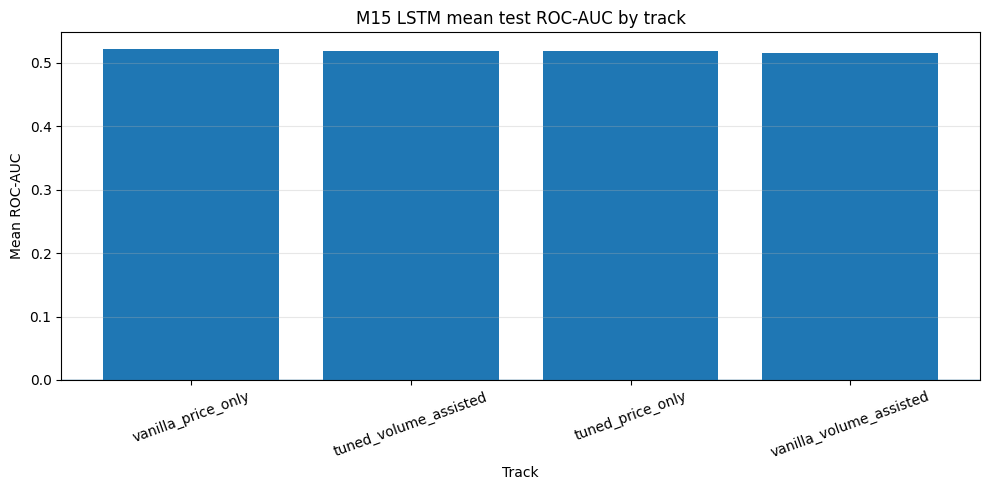

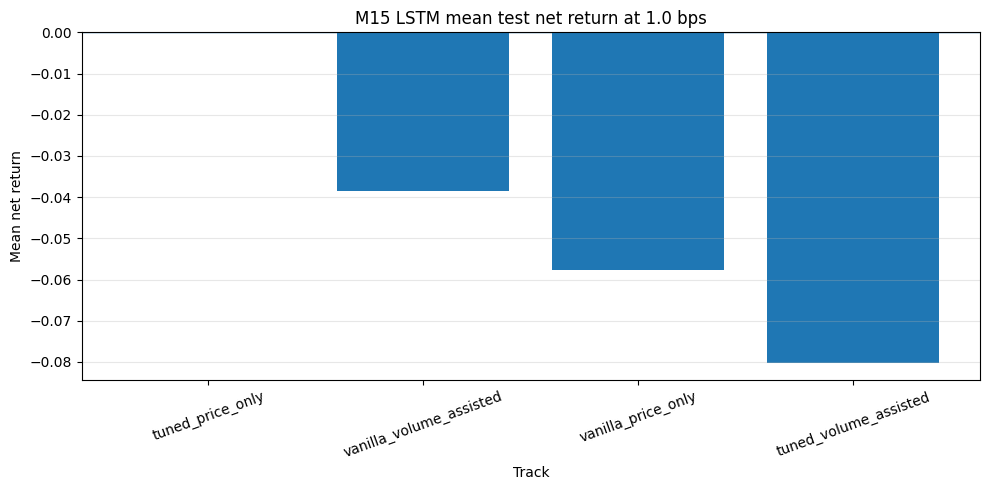

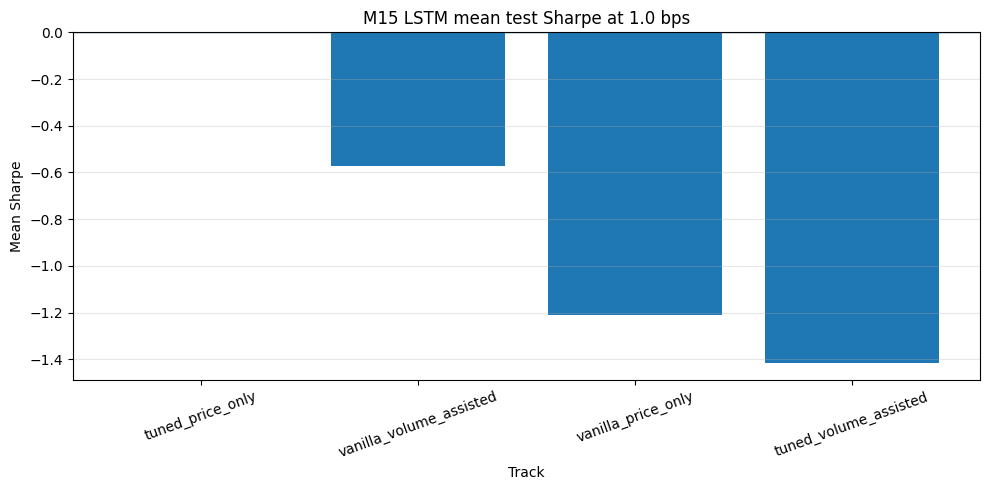

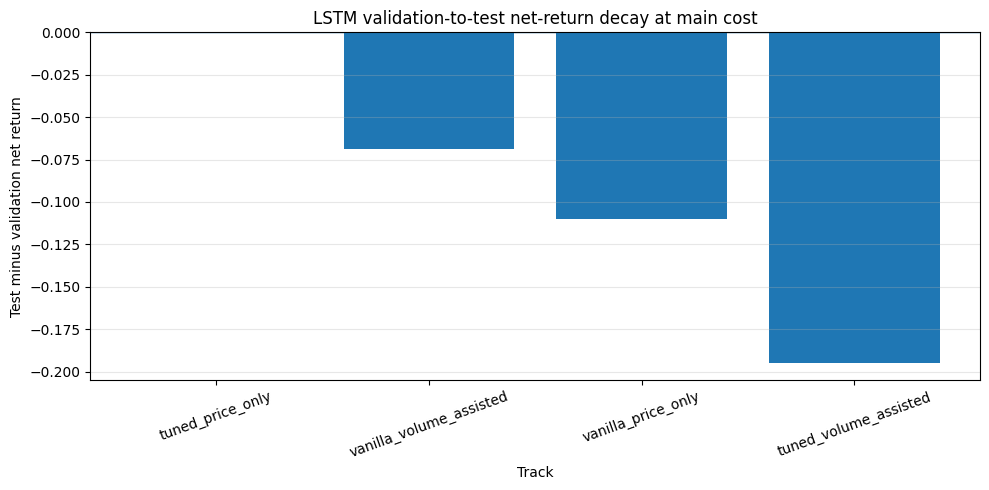

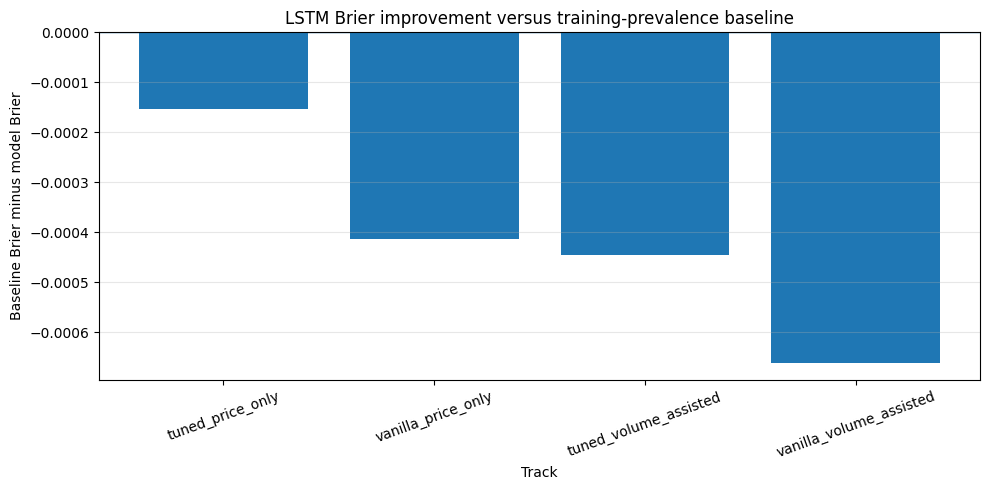

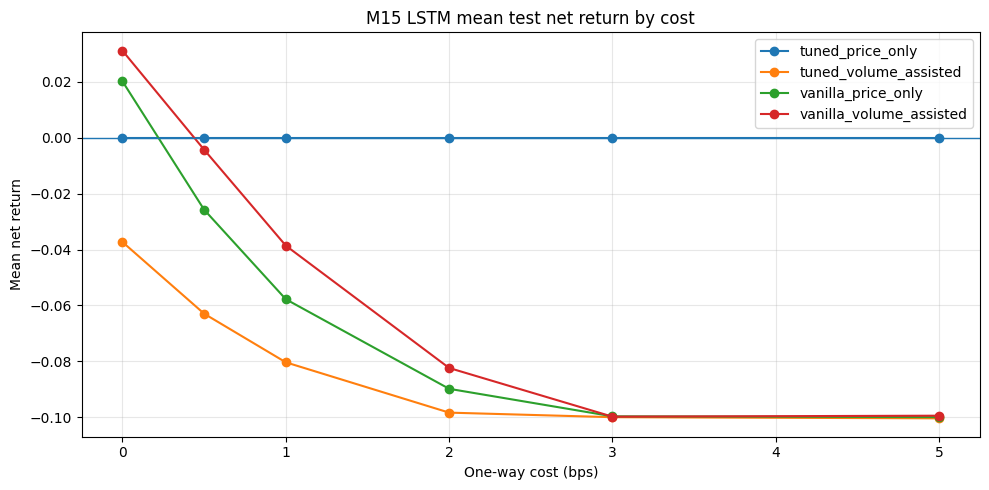

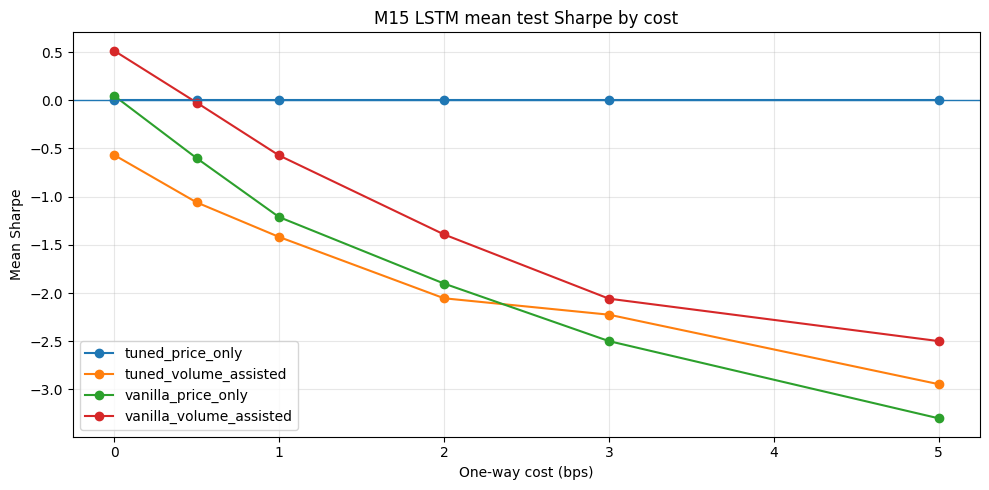

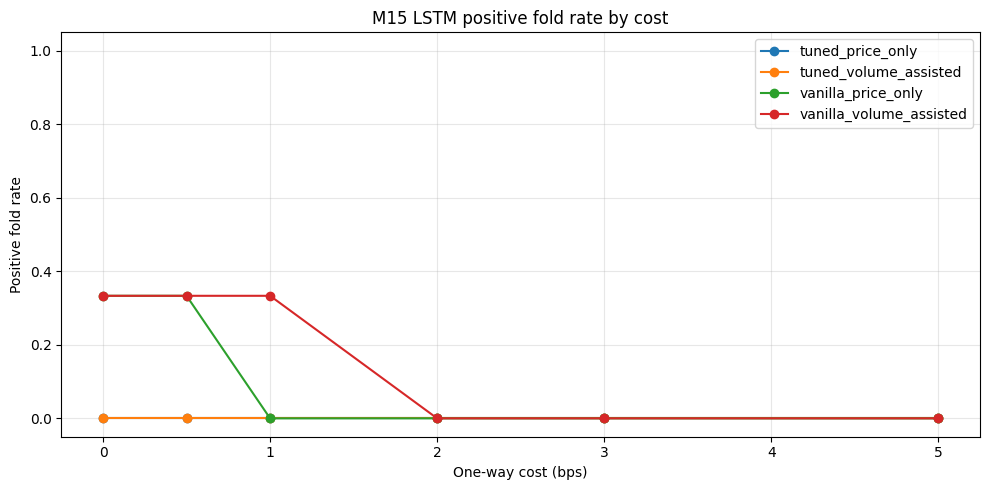

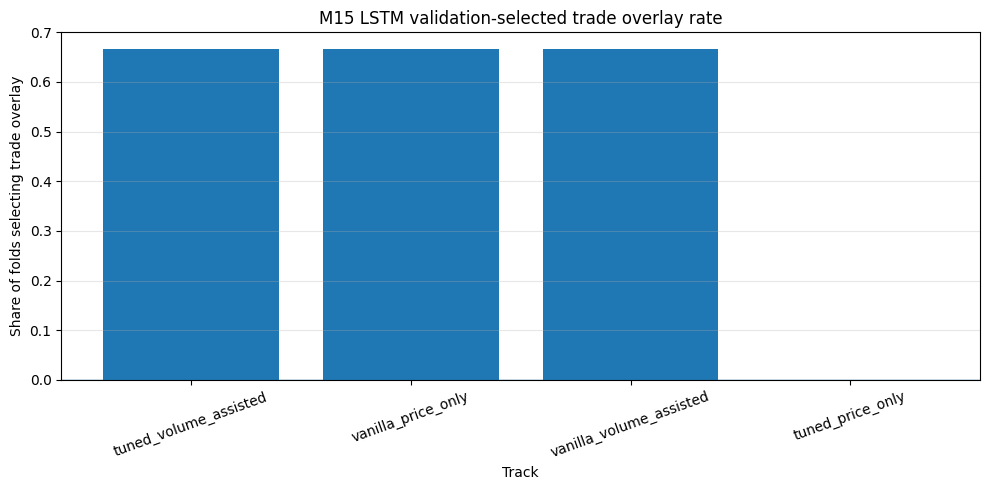

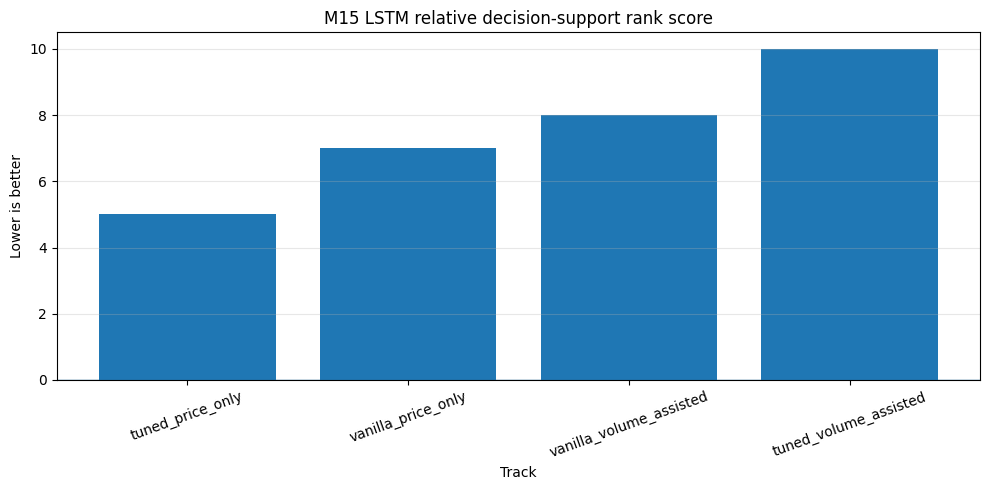

In [12]:
def save_bar(df: pd.DataFrame, x: str, y: str, title: str, ylabel: str, filename: str, rotation: int = 20):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(df[x].astype(str), df[y])
    ax.axhline(0, linewidth=1)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Track')
    ax.tick_params(axis='x', rotation=rotation)
    ax.grid(axis='y', alpha=0.3)
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / filename, dpi=160)
    plt.show()

save_bar(track_summary.sort_values('mean_roc_auc', ascending=False), 'track', 'mean_roc_auc', 'M15 LSTM mean test ROC-AUC by track', 'Mean ROC-AUC', 'm15_lstm_harmonised_roc_auc_by_track.png')
save_bar(track_summary.sort_values('mean_net_return', ascending=False), 'track', 'mean_net_return', f'M15 LSTM mean test net return at {MAIN_SELECTION_COST_BPS} bps', 'Mean net return', 'm15_lstm_harmonised_net_return_main_cost_by_track.png')
save_bar(track_summary.sort_values('mean_sharpe', ascending=False), 'track', 'mean_sharpe', f'M15 LSTM mean test Sharpe at {MAIN_SELECTION_COST_BPS} bps', 'Mean Sharpe', 'm15_lstm_harmonised_sharpe_main_cost_by_track.png')
save_bar(decay_summary.sort_values('mean_net_return_decay', ascending=False), 'track', 'mean_net_return_decay', 'LSTM validation-to-test net-return decay at main cost', 'Test minus validation net return', 'm15_lstm_harmonised_validation_to_test_decay.png')
save_bar(calibration_summary.sort_values('mean_brier_improvement_vs_baseline', ascending=False), 'track', 'mean_brier_improvement_vs_baseline', 'LSTM Brier improvement versus training-prevalence baseline', 'Baseline Brier minus model Brier', 'm15_lstm_harmonised_brier_improvement.png')

fig, ax = plt.subplots(figsize=(10, 5))
for track in aggregate_trading['track'].unique():
    subset = aggregate_trading[aggregate_trading['track'] == track].sort_values('cost_bps')
    ax.plot(subset['cost_bps'], subset['mean_net_return'], marker='o', label=track)
ax.axhline(0, linewidth=1)
ax.set_title('M15 LSTM mean test net return by cost')
ax.set_xlabel('One-way cost (bps)')
ax.set_ylabel('Mean net return')
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'm15_lstm_harmonised_net_return_by_cost.png', dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
for track in aggregate_trading['track'].unique():
    subset = aggregate_trading[aggregate_trading['track'] == track].sort_values('cost_bps')
    ax.plot(subset['cost_bps'], subset['mean_sharpe'], marker='o', label=track)
ax.axhline(0, linewidth=1)
ax.set_title('M15 LSTM mean test Sharpe by cost')
ax.set_xlabel('One-way cost (bps)')
ax.set_ylabel('Mean Sharpe')
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'm15_lstm_harmonised_sharpe_by_cost.png', dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
for track in aggregate_trading['track'].unique():
    subset = aggregate_trading[aggregate_trading['track'] == track].sort_values('cost_bps')
    ax.plot(subset['cost_bps'], subset['positive_fold_rate'], marker='o', label=track)
ax.set_title('M15 LSTM positive fold rate by cost')
ax.set_xlabel('One-way cost (bps)')
ax.set_ylabel('Positive fold rate')
ax.set_ylim(-0.05, 1.05)
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'm15_lstm_harmonised_positive_fold_rate_by_cost.png', dpi=160)
plt.show()

save_bar(
    overlay_summary.assign(trade_rate=lambda x: x['selected_trade_folds'] / x['folds']).sort_values('trade_rate', ascending=False),
    'track', 'trade_rate', 'M15 LSTM validation-selected trade overlay rate',
    'Share of folds selecting trade overlay', 'm15_lstm_harmonised_overlay_selected_trade_rate.png'
)
save_bar(track_summary.sort_values('simple_rank_score'), 'track', 'simple_rank_score', 'M15 LSTM relative decision-support rank score', 'Lower is better', 'm15_lstm_harmonised_track_score.png')


## 9. Findings draft

This machine-generated draft is based only on the harmonised LSTM experiment. It must be reviewed against the executed outputs before use in the capstone report. The archived earlier LSTM development results must not be mixed into the final cross-model comparison.


In [13]:
best = track_summary.iloc[0]
best_auc = track_summary.sort_values('mean_roc_auc', ascending=False).iloc[0]
positive_tracks = track_summary[track_summary['mean_net_return'] > 0]

lines = [
    'Notebook 4 — Harmonised M15 LSTM full walk-forward evaluation findings draft',
    '=' * 84,
    '',
    f"Best relative track at {MAIN_SELECTION_COST_BPS} bps: {best['track']}",
    f"  Mean ROC-AUC: {best['mean_roc_auc']:.6f}",
    f"  Mean net return: {best['mean_net_return']:.6f}",
    f"  Mean Sharpe: {best['mean_sharpe']:.6f}",
    f"  Positive fold rate: {best['positive_fold_rate']:.3f}",
    '',
    f"Best classification track: {best_auc['track']} with mean ROC-AUC {best_auc['mean_roc_auc']:.6f}.",
    '',
]
if positive_tracks.empty:
    lines.append(f'At {MAIN_SELECTION_COST_BPS} bps, no LSTM track achieved positive mean net return across folds.')
else:
    lines.append(f"At {MAIN_SELECTION_COST_BPS} bps, positive mean-net-return tracks: {', '.join(positive_tracks['track'])}.")
lines.extend([
    '',
    'Methodological interpretation:',
    '- Neural hyperparameters were selected on an inner chronological validation year inside the outer training period.',
    '- The outer validation year was reserved for overlay selection.',
    '- The test year was evaluated once after the model and overlay were frozen.',
    '- Sequence windows crossing non-contiguous M15 gaps were excluded.',
    '- Persistent Optuna studies and configuration fingerprinting supported reproducible resume behaviour.',
    '- The final 2025–2026 holdout remained untouched.',
    '',
    'Critical note:',
    'LSTM complexity is justified only if recurrent sequence modelling improves unseen test performance. A better validation score alone is not evidence of a trading edge. Transaction-cost survival, fold consistency, drawdown and validation-to-test decay remain decisive.',
])

findings_path = OUTPUT_DIR / 'm15_lstm_harmonised_full_findings_draft.txt'
findings_path.write_text('\n'.join(lines), encoding='utf-8')
print(findings_path.read_text(encoding='utf-8'))


Notebook 4 — Harmonised M15 LSTM full walk-forward evaluation findings draft

Best relative track at 1.0 bps: tuned_price_only
  Mean ROC-AUC: 0.518844
  Mean net return: 0.000000
  Mean Sharpe: 0.000000
  Positive fold rate: 0.000

Best classification track: vanilla_price_only with mean ROC-AUC 0.522127.

At 1.0 bps, no LSTM track achieved positive mean net return across folds.

Methodological interpretation:
- Neural hyperparameters were selected on an inner chronological validation year inside the outer training period.
- The outer validation year was reserved for overlay selection.
- The test year was evaluated once after the model and overlay were frozen.
- Sequence windows crossing non-contiguous M15 gaps were excluded.
- Persistent Optuna studies and configuration fingerprinting supported reproducible resume behaviour.
- The final 2025–2026 holdout remained untouched.

Critical note:
LSTM complexity is justified only if recurrent sequence modelling improves unseen test performan

## 10. Output inventory


In [14]:
print('Tables:')
for path in sorted(TABLE_DIR.glob('*.csv')):
    print(' -', path.relative_to(OUTPUT_DIR))
print('\nOptuna study artefacts:')
for path in sorted(OPTUNA_DIR.glob('*')):
    print(' -', path.relative_to(OUTPUT_DIR))
print('\nModels:')
for path in sorted(MODEL_DIR.glob('*.keras')):
    print(' -', path.relative_to(OUTPUT_DIR))
print('\nPreprocessing artefacts:')
for path in sorted(SCALER_DIR.glob('*')):
    print(' -', path.relative_to(OUTPUT_DIR))
print('\nConfiguration:')
for path in sorted(CONFIG_DIR.glob('*')):
    print(' -', path.relative_to(OUTPUT_DIR))
print('\nFigures:')
for path in sorted(FIGURE_DIR.glob('*.png')):
    print(' -', path.relative_to(OUTPUT_DIR))
print('\nFindings draft:')
print(' -', (OUTPUT_DIR / 'm15_lstm_harmonised_full_findings_draft.txt').relative_to(OUTPUT_DIR))


Tables:
 - tables/aggregate_test_classification_summary.csv
 - tables/aggregate_test_trading_summary_by_cost.csv
 - tables/calibration_baseline_comparison.csv
 - tables/classification_validation_to_test_decay_by_fold.csv
 - tables/fold_rows_m15_lstm.csv
 - tables/lstm_classification_metrics_by_fold.csv
 - tables/lstm_training_histories.csv
 - tables/lstm_training_log.csv
 - tables/overlay_viability_summary_at_main_cost.csv
 - tables/price_vs_volume_delta_summary_at_main_cost.csv
 - tables/selected_overlay_by_fold.csv
 - tables/temporal_role_summary.csv
 - tables/test_predictions_by_track_fold.csv
 - tables/test_trading_metrics_by_fold_cost.csv
 - tables/track_summary_at_main_cost.csv
 - tables/tuning_study_summary.csv
 - tables/validation_overlay_grid_metrics_at_main_cost.csv
 - tables/validation_to_test_decay_by_fold_at_main_cost.csv
 - tables/validation_to_test_decay_summary_at_main_cost.csv
 - tables/vanilla_vs_tuned_delta_summary_at_main_cost.csv

Optuna study artefacts:
 - optuna_